# Imports and functions

In [1]:
import pandas as pd
import numpy as np
from os.path import join

import matplotlib.pyplot as plt
import plotly.express as px

import pulp as p

from IPython.display import display, Markdown

pd.set_option('display.max_columns' ,1000)
pd.set_option('display.max_rows', 1000)

import warnings
warnings.filterwarnings('ignore')

import logging
from datetime import datetime

In [2]:
def format_val(x):
    if pd.isna(x):  # Check if the value is NaN
        return np.nan  # Return NaN for missing values
    x_int = int(x)  # Convert to integer
    s = str(x_int)[-6:]  # Take the last 6 digits
    return "C" + s.zfill(6)  # Format with leading zeros

# Define material addition list

In [3]:
material_columns = [
    'Fe-Cr\nHi-C', 
    'Fe-Cr\nLo-C', 
    'Fe-Mn \nMb', 
    'Fe-Mn\nHi-C', 
    'Fe-Mn\nLo-C', 
    'Fe-Si', 
    'Fe-Si\n0-50mm', 
    'Ferro\nNiobium', 
    'Ferro\nTitanium', 
    'Ferro\nVanadium', 
    'Si-Mn\n10-50mm', 
    'Si-Mn\n25-50mm', 
    'SiMn LP\n25_50mm', 
    'SiMn\n12-25mm', 
    'P.Coke',
]

In [4]:
extra_additions = [
    'Chargeable\nSteel Scrap',
    'NFScrap\nCu',
    'Ingot Cu',
    'Cu Cathode',
    'LIME',
    'Calcined \nDolomite',
    'Calcined \nBauxite',
    'Cal Baux\n10-40mm',
    'Iron Ore\nBF Grade',
    'Iron Ore\nOH Grade',
    'Nut Coke',
    'Coke Breeze',
    'Al.\nShot',
    'Al\nIngot',
]

In [5]:
aluminium_additions = [
    'Al.\nShot',
    'Al\nIngot',
    'Al\nCube',
    'Al\nWire'
]

carbon_additions = [
    'Nut Coke',
    'Coke Breeze',
]

# Read Data

In [6]:
PATH_RAW = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/'

In [7]:
PATH_INT = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/02_intermediate'

## Read bulk additions data

In [8]:
path_bof1 = join(PATH_RAW, 'BOF/common process/Converter Material 2023-24.xlsx')
path_bof2 = join(PATH_RAW, 'BOF/common process/Converter Material 2024-25.xlsx')
path_bof3 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter Material 2025-26 till sep.xlsx'
path_bof4 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter 2025-26..1.xlsx'
path_bof5 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Conv.Material 2025-26..Oct 25.xlsx'
path_bof6 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/BOF Material 2025-26..Nov 25.xlsx'
path_bof7 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/BOF Material 2025-26..Dec 25[70].xlsx'


path_lf1 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/SRU/LF Material 2023-24.xlsx'
path_lf2 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/SRU/LF Material 2024-25.xlsx'
path_lf3 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/SRU/LF Material 2025-26.xlsx'
path_lf4 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/SRU/LF material..2025..1.xlsx'
path_lf5 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/SRU/Material 2025-26..Oct 25.xlsx'
path_lf6 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/LF Material 2025-26..Nov 25[95].xlsx'
path_lf7 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/LF Material 2025-26..Dec 25.xlsx'

Here we create an empty dataframe where we will combine all data from the BOF file, we first loop over all the files and then read them using the pd.ExcelFile method, then we go over sheet by sheet and then parse that sheet in the dataframe.
Then we check if the data exist in the dataframe, if it does then we convert it into a standard datetime format,all the rows where the date time has NaT we drop it,then we concatenate the resulting df into the empty initialized dataframe.

In [ ]:
mat_df_bof = pd.DataFrame() # Initialize an empty DataFrame to store the combined data from all the BOF material files

for file in [path_bof1, path_bof2, path_bof3, path_bof4, path_bof5, path_bof6, path_bof7]: # Loop over the list of files
    txl = pd.ExcelFile(file) # Load the Excel file
    # print(file) 
    for sheet in txl.sheet_names: # Loop over the sheet names in the Excel file
        tdf = txl.parse(sheet)# Parse the sheet into a DataFrame
        # print(sheet, tdf.shape)
        if 'Date' in tdf.columns:# Check if the 'Date' column exists in the DataFrame
            tdf['Date']=pd.to_datetime(tdf['Date'],format="%d-%m-%Y", errors='coerce') # Convert the 'Date' column to datetime format, coercing errors to NaT
            tdf = tdf.dropna(subset=['Date']) # Drop rows where the 'Date' column has NaT values (i.e., rows with invalid dates)
            # print(sheet, tdf['Date'].min(), tdf['Date'].max(), tdf.shape) 
            mat_df_bof = pd.concat([mat_df_bof, tdf], axis=0)# Concatenate the current DataFrame with the main DataFrame along the rows (axis=0)
            # print(mat_df_bof.shape)

mat_df_bof = mat_df_bof.drop(columns=['Unnamed: 0']) # Drop the 'Unnamed: 0' column from the DataFrame, which is likely an unnecessary index column created during Excel parsing

In [10]:
mat_df_bof.tail(5)

,Date,Heat No,Grade,HM,Steel\nScrap,Chargeable\nSteel Scrap,Wear\n Scrap,NFScrap\nCu,Cu Mould,Ingot Cu,Cu Cathode,LIME,Limestone,Limestone\nChip,Calcined \nDolomite,Calcined \nBauxite,Cal Baux\n10-40mm,Cal Carb\nDS,Cal\nAl,Calcium\nSilicide,Dolomite \nRMP2 Gr,Iron Ore\nBF Grade,Iron Ore\nOH Grade,CASI\nWire,CAFE Cored\nWire,MG-97,P.Coke,Nut Coke,Coke Breeze,SiMn\n12-25mm,SiMn LP\n25_50mm,Si-Mn\n25-50mm,Si-Mn\n10-50mm,Fe-Si,Fe-Si\n0-50mm,Ferro\nVanadium,Fe-Mn\nHi-C,Fe-Mn\nLo-C,Fe-Mn \nMb,Fe-Cr\nHi-C,Fe-Cr\nLo-C,Ferro\nTitanium,Ferro\nNiobium,FEP,Al.\nShot,Al\nIngot,Al\nWire,Al\nCube,Pallet,LDSF,Ferro\nBoron,Coil\nFlipping
873,2025-12-16,C113896,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,9.747,0,0,5.096,0,0,0,0,0,0,4.178,0.0,0.0,0,0,311,0.1,0.0,0,0,0,2312,300,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0
874,2025-12-16,C113897,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,8.501,0,0,5.938,0,232,0,0,0,0,2.459,0.0,0.0,0,0,321,0.1,0.0,0,0,0,2207,344,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0
875,2025-12-16,C113898,NaN,173.0,0,13.0,0,0,0,0,0,11.034,0,0,4.599,0,286,0,0,0,0,1.312,0.0,0.0,0,0,1096,0.1,0.0,0,2662,0,0,278,20,80,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0
876,2025-12-16,C113899,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,10.551,0,0,4.008,0,0,0,0,0,0,0.606,0.0,0.0,0,0,286,0.1,0.0,0,0,0,2117,442,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0
877,2025-12-16,C113900,NaN,173.0,0,13.0,0,0,0,0,0,11.430,0,0,5.915,0,201,0,0,0,0,2.857,0.0,0.0,0,0,1146,0.1,0.0,0,2838,0,0,244,20,80,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Read trim addition data

In [11]:
mat_df_lf = pd.DataFrame()

for file in [path_lf1, path_lf2, path_lf3, path_lf4, path_lf5, path_lf6, path_lf7]:
    txl = pd.ExcelFile(file)
    # print(file)
    for sheet in txl.sheet_names:
        tdf = txl.parse(sheet)
        # print(sheet, tdf.shape)
        if 'Date' in tdf.columns:
            tdf['Date']=pd.to_datetime(tdf['Date'],format="%d-%m-%Y", errors='coerce')
            tdf = tdf.dropna(subset=['Date'])
            # print(sheet, tdf['Date'].min(), tdf['Date'].max(), tdf.shape)
            mat_df_lf = pd.concat([mat_df_lf, tdf], axis=0)
            # print(mat_df_lf.shape)

mat_df_lf = mat_df_lf.drop(columns=['Unnamed: 0', 'S.N'])

## Read combined material addition data

In [12]:
key_columns = ['Date', 'Heat No', 'Grade']

In [ ]:
# Merge the two dataframes on the key columns
merged_df = pd.merge(mat_df_bof.drop_duplicates(subset=key_columns), mat_df_lf.drop_duplicates(subset=key_columns), on=key_columns, how='inner', suffixes=('_bof', '_lf')) # Perform an inner merge on the key columns, keeping only rows that have matching values in both dataframes. The suffixes '_bof' and '_lf' are added to distinguish columns from the two dataframes in case of name clashes.

# Identify columns to sum (all columns except the key columns)
columns_to_sum = [col for col in merged_df.columns if col not in key_columns] # Create a new DataFrame with the key columns and the summed material columns

In [ ]:
for col in [col for col in merged_df if col.endswith('_bof')]: # Loop over columns that end with '_bof' to sum them with their corresponding '_lf' columns
    merged_df[col.replace('_bof','')] = merged_df[col] + merged_df[col.replace('_bof','_lf')] # Sum the corresponding columns from the BOF and LF dataframes, creating new columns without the suffixes. For each column that ends with '_bof', we take its value and add it to the corresponding column that ends with '_lf', storing the result in a new column with the same name but without the suffix.

In [15]:
mat_df_comb = merged_df.copy()

In [ ]:
mat_df_comb = mat_df_comb.drop(columns=[col for col in mat_df_comb if col.endswith('_bof')]).drop(columns=[col for col in mat_df_comb if col.endswith('_lf')]) 
 # Drop the original columns that end with '_bof' and '_lf' since we have already created the summed columns without the suffixes. This leaves us with a DataFrame that contains only the key columns and the combined material columns.

In [17]:
mat_df_comb

,Date,Heat No,Grade,HM,Steel\nScrap,Chargeable\nSteel Scrap,Wear\n Scrap,NFScrap\nCu,Cu Mould,Ingot Cu,Cu Cathode,LIME,Limestone,Limestone\nChip,Calcined \nDolomite,Calcined \nBauxite,Cal Baux\n10-40mm,Cal Carb\nDS,Cal\nAl,Calcium\nSilicide,Dolomite \nRMP2 Gr,Iron Ore\nBF Grade,Iron Ore\nOH Grade,CASI\nWire,CAFE Cored\nWire,MG-97,P.Coke,Nut Coke,Coke Breeze,SiMn\n12-25mm,SiMn LP\n25_50mm,Si-Mn\n25-50mm,Si-Mn\n10-50mm,Fe-Si,Fe-Si\n0-50mm,Ferro\nVanadium,Fe-Mn\nHi-C,Fe-Mn\nLo-C,Fe-Mn \nMb,Fe-Cr\nHi-C,Fe-Cr\nLo-C,Ferro\nTitanium,Ferro\nNiobium,FEP,Al.\nShot,Al\nIngot,Al\nWire,Al\nCube,Pallet,LDSF,Ferro\nBoron,Coil\nFlipping
0,2023-04-01,C056530,45 C 8,171.0,0,12.0,0,0,0,0,0,10.000,0.0,0.0,4.000,0,0,0,0,0,0,0.000,2.0,0.00,0.0,0,720,0.3,0.0,0,0,0,2050.0,400.0,0,0,0,0.0,0,0,0,0,0,0,30,0,0,0,0,0,0,0
1,2023-04-01,C056531,SAIL SEQR,170.0,0,13.0,0,0,0,0,0,14.600,0.0,0.0,4.000,0,0,0,0,0,0,0.000,3.0,35.55,0.0,0,260,0.3,0.0,0,0,0,2350.0,450.0,0,0,0,0.0,0,0,0,0,0,0,30,40,0,0,0,0,0,0
2,2023-04-01,C056532,45 C 8,170.0,0,13.0,0,0,0,0,0,13.100,0.0,0.0,3.000,0,0,0,0,0,0,0.000,3.3,0.00,0.0,0,680,0.3,0.0,0,0,0,2180.0,400.0,0,0,0,0.0,0,0,0,0,0,0,30,0,0,0,0,0,0,0
3,2023-04-01,C056533,IS2830C20MMNC (RC),170.0,0,13.0,0,0,0,0,0,11.600,0.0,0.0,4.000,0,0,0,0,0,0,0.000,2.0,35.55,0.0,0,320,0.3,0.0,0,0,0,2150.0,550.0,0,0,0,0.0,0,0,0,0,0,0,30,40,0,0,0,0,0,0
4,2023-04-01,C056534,SAIL SEQR,170.0,0,13.0,0,0,0,0,0,9.900,0.0,0.0,4.000,0,0,0,0,0,0,0.000,3.0,35.55,0.0,0,340,0.3,0.0,0,0,0,2460.0,400.0,0,0,0,0.0,0,0,0,0,0,0,30,40,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54003,2025-12-16,C113896,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,10.147,0.0,0.0,5.096,0,0,0,0,0,0,4.178,0.0,0.00,0.0,0,456,0.1,0.0,0,0,0,2712.0,570.0,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0
54004,2025-12-16,C113897,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,9.201,0.0,0.0,5.938,0,232,0,0,0,0,2.459,0.0,0.00,0.0,0,436,0.1,0.0,0,0,0,2557.0,544.0,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0
54005,2025-12-16,C113898,NaN,173.0,0,13.0,0,0,0,0,0,11.784,0.0,0.0,4.599,0,286,0,0,0,0,1.312,0.0,48.00,0.0,0,1186,0.1,0.0,0,2662,0,280.0,378.0,20,80,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0
54006,2025-12-16,C113899,SAIL SEQR,173.0,0,13.0,0,0,0,0,0,10.551,0.0,0.0,4.008,0,0,0,0,0,0,0.606,0.0,0.00,0.0,0,396,0.1,0.0,0,0,0,2437.0,617.0,0,0,0,NaN,0,0,0,0,0,0,0,40,0,0,0,0,0,0


### Convert materials added to tons

In [ ]:
mat_df_comb[material_columns + extra_additions] = mat_df_comb[material_columns + extra_additions].fillna(0)/1000 # Fill NaN values with 0 and convert the material quantities from kg to tonnes by dividing by 1000. This is done for all columns that are in the list of material columns and extra additions.
mat_df_bof[material_columns + extra_additions] = mat_df_bof[material_columns + extra_additions].fillna(0)/1000 # Fill NaN values with 0 and convert the material quantities from kg to tonnes by dividing by 1000. This is done for all columns that are in the list of material columns and extra additions.
mat_df_lf[material_columns + extra_additions] = mat_df_lf[material_columns + extra_additions].fillna(0)/1000 # Fill NaN values with 0 and convert the material quantities from kg to tonnes by dividing by 1000. This is done for all columns that are in the list of material columns and extra additions.

In [ ]:
mat_df_comb['all_ferroalloy_wt'] = mat_df_comb[material_columns].sum(axis=1) # Create a new column 'all_ferroalloy_wt' in the combined DataFrame that contains the sum of all the material columns for each row. This gives us the total weight of all ferroalloys used in each heat.
mat_df_bof['all_ferroalloy_wt'] = mat_df_bof[material_columns].sum(axis=1) # Create a new column 'all_ferroalloy_wt' in the BOF DataFrame that contains the sum of all the material columns for each row. This gives us the total weight of all ferroalloys used in each heat for the BOF process.
mat_df_lf['all_ferroalloy_wt'] = mat_df_lf[material_columns].sum(axis=1) # Create a new column 'all_ferroalloy_wt' in the LF DataFrame that contains the sum of all the material columns for each row. This gives us the total weight of all ferroalloys used in each heat for the LF process.

### Add column identifiers for ferro alloy additions

In [ ]:
mat_df_bof.columns = ["BULK_" + col if col not in ['Date', 'Heat No', 'Grade', 'HM'] else col for col in mat_df_bof] # Prefix 'BULK_' to all columns in the BOF DataFrame except for the key columns and 'HM' column. This is done to distinguish the BOF material columns from the LF material columns when we merge them later on.

In [ ]:
mat_df_lf.columns = ["TRIM_" + col if col not in ['Date', 'Heat No', 'Grade', 'HM'] else col for col in mat_df_lf] # Prefix 'TRIM_' to all columns in the LF DataFrame except for the key columns and 'HM' column. This is done to distinguish the LF material columns from the BOF material columns when we merge them later on.

In [ ]:
mat_df_comb.columns = ["COMB_" + col if col not in ['Date', 'Heat No', 'Grade', 'HM'] else col for col in mat_df_comb] # Prefix 'COMB_' to all columns in the combined DataFrame except for the key columns and 'HM' column. This is done to distinguish the combined material columns from the individual BOF and LF material columns when we merge them later on.

### Combined ferro alloy additions data

In [ ]:
ferro = mat_df_comb.drop_duplicates(subset=['Heat No']).merge(
    mat_df_bof[['Heat No']+[col for col in mat_df_bof if col.startswith('BULK_')]].drop_duplicates(subset=['Heat No']),
    on=['Heat No'],
    how='left'
).merge(
    mat_df_lf[['Heat No']+[col for col in mat_df_lf if col.startswith('TRIM_')]].drop_duplicates(subset=['Heat No']),
    on=['Heat No'],
    how='left'
) # Create a new DataFrame 'ferro' by merging the combined DataFrame with the BOF and LF DataFrames on the 'Heat No' column. 
  # We take only the columns that start with 'BULK_' from the BOF DataFrame 
  # and 'TRIM_' from the LF DataFrame to keep only the material columns,
  # and we drop duplicates based on 'Heat No' to ensure we have one row per heat.

ferro.shape # Display the shape of the 'ferro' DataFrame.

(54008, 151)

## So we have a data frame named ferro which tells us for a specific heat of a specific grade is consuming how much material for the past three years

## Read blow data

In [ ]:
process1 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter 2023-24.xlsx', sheet_name="datagrid1", header=[0,1])
process2 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Blows FY 2024-25.xlsx', sheet_name="datagrid1", header=[0,1])
process3 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter 2025-26.xlsx', sheet_name="datagrid1", header=[0,1])
process4 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter 2025-26..1.xlsx', sheet_name="datagrid1", header=[0,1])
process5 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/Converter 2025-26 Oct25.xlsx', sheet_name="datagrid1", header=[0,1])
process6 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/Converter 2025-26..Nov25.xlsx', sheet_name="datagrid1", header=[0,1])
process7 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/Converter 2025-26..Dec25.xlsx', sheet_name="datagrid1", header=[0,1])

# Flatten column names
process1.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process1.columns.values
] # Flatten column names for process1 by joining multi-level column names with an underscore, stripping whitespace, and ignoring 'nan' and 'Unnamed' columns. This results in cleaner column names for easier access and analysis.
process2.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process2.columns.values
] # Flatten column names for process2 by joining multi-level column names with an underscore, stripping whitespace, and ignoring 'nan' and 'Unnamed' columns. This results in cleaner column names for easier access and analysis.
process3.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process3.columns.values
] # Flatten column names for process3 by joining multi-level column names with an underscore, stripping whitespace, and ignoring 'nan' and 'Unnamed' columns. This results in cleaner column names for easier access and analysis.
process4.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process4.columns.values
]
process5.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process5.columns.values
]
process6.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process6.columns.values
]
process7.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in process7.columns.values
]

In [25]:
process1.shape, process2.shape, process3.shape, process4.shape, process5.shape, process6.shape, process7.shape

((20957, 36),
 (21528, 20),
 (7072, 36),
 (3210, 20),
 (1934, 20),
 (1806, 20),
 (894, 20))

In [26]:
blows_combined = pd.concat([process1, process2, process3, process4, process5, process6, process7], ignore_index=True)
blows_combined = blows_combined.dropna(subset=['Heat \nNo.'])
blows_combined.shape

(57390, 36)

## Read caster data

In [27]:
cast1 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/CCP/Caster Common/CCP 2023-24.xlsx', sheet_name="datagrid1", header=[0,1])
cast2 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/CCP/Caster Common/CASTER FY 2024-25.xlsx', sheet_name="datagrid1", header=[0,1])
cast3 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/CCP/Caster Common/CCP 2025-26.xlsx', sheet_name="datagrid1", header=[0,1])
cast4 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/CCP/Caster Common/CCP 2025-26..1.xlsx', sheet_name="datagrid1", header=[0,1])
cast5 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/CCP/Caster Common/CCP 2025-26..Oct 25.xlsx', sheet_name="datagrid1", header=[0,1])
cast6 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/CCP 2025-26..Nov 25.xlsx', sheet_name="datagrid1", header=[0,1])
cast7 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/CCP 2025-26..Dec 25.xlsx', sheet_name="datagrid1", header=[0,1])

# Flatten column names
cast1.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast1.columns.values
]
cast2.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast2.columns.values
]
cast3.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast3.columns.values
]
cast4.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast4.columns.values
]
cast5.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast5.columns.values
]
cast6.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast6.columns.values
]
cast7.columns = [
    "_".join([str(c).strip() for c in col if str(c) != 'nan' and not c.startswith("Unnamed")])
    for col in cast7.columns.values
]

cast1.shape, cast2.shape, cast3.shape, cast4.shape, cast5.shape, cast6.shape, cast7.shape

((20948, 49),
 (2500, 39),
 (7070, 49),
 (3213, 39),
 (1937, 39),
 (1799, 39),
 (892, 39))

In [28]:
caster_combined = pd.concat([cast1, cast2, cast3, cast4, cast5, cast6, cast7], ignore_index=True)
caster_combined = caster_combined.dropna(subset=['Heat\nNo.'])
caster_combined.shape

(38359, 49)

## Read blows process params data

In [29]:
process_data1 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/sms3_process_data.xlsx')
process_data2 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/BOF/common process/SMS3_ProcessData_Aug2025to30oct2025.xlsx')
process_data3 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/Converter Process Data 2025 Nov-Dec.xlsx')

In [ ]:
process_data = pd.concat([process_data1, process_data2, process_data3], axis=0) # Combine the process data from multiple Excel files into a single DataFrame by concatenating them along the rows (axis=0)

In [ ]:
process_data["TAPPING_DATE"] = pd.to_datetime(process_data["TAPPING_DATE"], format="%Y-%m-%d %H:%M:%S", errors="coerce") # Convert the 'TAPPING_DATE' column to datetime format, coercing errors to NaT for any invalid date formats. This ensures that the tapping dates are in a consistent datetime format for further analysis.
process_data.shape

(115160, 60)

In [ ]:
process_data = process_data[process_data['HEATNO'].notna()] # Filter the process data to keep only rows where the 'HEATNO' column is not null. This ensures that we only have valid heat numbers in our process data for further analysis.

In [ ]:
process_data['HEATNO_UPDATED'] = process_data['HEATNO'].apply(format_val) # Create a new column 'HEATNO_UPDATED' by applying the 'format_val' function to the 'HEATNO' column. This function formats the heat numbers to a consistent format with a 'C' prefix and leading zeros, which can help in matching heat numbers across different datasets.

In [34]:
process_data = process_data.drop_duplicates(subset=['HEATNO_UPDATED'], keep='last')

## Read output chemistry

In [ ]:
srtm_file1 = join(PATH_RAW, 'SRTM/SRTM503 2023-24.xls')
srtm_file2 = join(PATH_RAW, 'SRTM/SRTM503 2024-25.xls')
srtm_file3 = join(PATH_RAW, 'SRTM/SRTM503 2025-26.xls')
srtm_file4 = join(PATH_RAW, 'SRTM/SRTM503 2025-26..1.xls')
srtm_file5 = join(PATH_RAW, 'SRTM/SRTM503 2025-26..Oct 25.xls')
srtm_file7 = r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/SRTM503 Dec.xls'

def fun1(file): # Define a function 'fun1' that takes a file path as input and processes the Excel file to extract the data into a DataFrame. This function is designed to handle the specific structure of the SRTM Excel files, which have headers in the first 8 rows and the actual data starting from the 9th row. The function reads the headers, processes merged cells, and then reads the data while assigning the correct headers to the columns.

    # --- STEP 1: Read top part to get headers ---
    raw = pd.read_excel(file, header=None, nrows=8)

    # Forward fill across merged cells
    raw = raw.fillna(method="ffill", axis=1).fillna(method="ffill", axis=0) # Fill NaN values by forward filling first across columns (axis=1) to handle merged cells that span multiple columns, and then across rows (axis=0) to handle merged cells that span multiple rows. This ensures that we get the correct headers even if they are merged in the original Excel file.

    # Take the last row of headers
    headers = raw.iloc[7].fillna("").tolist() # Take the 8th row (index 7) of the raw DataFrame as the header row, fill any NaN values with an empty string, and convert it to a list. This gives us the column headers for the actual data that starts from the 9th row in the Excel file.

    # --- STEP 2: Read the actual data ---
    df = pd.read_excel(file, header=None, skiprows=8)

    # Assign headers
    df.columns = headers

    # --- STEP 3: Merge duplicate columns ---
    # If duplicate columns (like 'SN' across 2 cols), keep only first non-null per row
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df['SN']=pd.to_numeric(df['SN'], errors='coerce')
    df=df[df['SN'].notna()]
    df['SN']=df['SN'].astype(int)


    return df

srtm_comp1 = fun1(srtm_file1)
srtm_comp2 = fun1(srtm_file2)
srtm_comp3 = fun1(srtm_file3)
srtm_comp4 = fun1(srtm_file4)
srtm_comp5 = fun1(srtm_file5)
srtm_comp7 = fun1(srtm_file7)

In [36]:
srtm_comp6 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/SRTM503 2025-26..Nov 25.xls.xlsx')

In [37]:
columns_to_keep = [
    'SN', 'Heat\nNo', '%C', '%Mn', '%P',
    '%S', '%Si', '%Al', '%Nb', '%V', '%Ti', '%Cu', '%Cr', '%Ni', '%Ca',
    '%N2', '%O2', '%Mo', 'TD\nHYD\nppm', 'M/c', 'TON',
    'TON excluding HB TB'
]

In [38]:
srtm_comp = pd.concat([
    srtm_comp1[columns_to_keep], 
    srtm_comp2[columns_to_keep], 
    srtm_comp3[columns_to_keep], 
    srtm_comp4[columns_to_keep], 
    srtm_comp5[columns_to_keep],
    srtm_comp6[columns_to_keep],
    srtm_comp7[columns_to_keep],
], ignore_index=True)

srtm_comp.shape

(57372, 22)

In [39]:
srtm_comp.columns = [col.replace('%', 'FINL_') for col in srtm_comp]

In [40]:
for col in ['FINL_C', 'FINL_Mn',
       'FINL_P', 'FINL_S', 'FINL_Si', 'FINL_Al', 'FINL_Nb', 'FINL_V',
       'FINL_Ti', 'FINL_Cu', 'FINL_Cr', 'FINL_Ni', 'FINL_Ca', 'FINL_N2',
       'FINL_O2', 'FINL_Mo', 'TON']:
    srtm_comp[col] = pd.to_numeric(srtm_comp[col]).fillna(0)

In [41]:
srtm_comp

,SN,Heat\nNo,FINL_C,FINL_Mn,FINL_P,FINL_S,FINL_Si,FINL_Al,FINL_Nb,FINL_V,FINL_Ti,FINL_Cu,FINL_Cr,FINL_Ni,FINL_Ca,FINL_N2,FINL_O2,FINL_Mo,TD\nHYD\nppm,M/c,TON,TON excluding HB TB
0,1.0,C056530,0.42,0.74,0.017,0.029,0.24,0.008,0.000,0.006,0.001,0.003,0.010,0.01,0.0,0.0,0.0,0.0,NR,CV1,163.323,163.323
1,2.0,C056531,0.21,0.78,0.015,0.028,0.19,0.007,0.000,0.007,0.001,0.003,0.012,0.01,0.0,0.0,0.0,0.0,NR,CK2,153.360,153.36
2,3.0,C056532,0.44,0.77,0.016,0.032,0.21,0.007,0.000,0.008,0.001,0.004,0.013,0.01,0.0,0.0,0.0,0.0,NR,CV1,175.947,175.947
3,4.0,C056533,0.19,0.78,0.013,0.027,0.18,0.008,0.000,0.008,0.001,0.005,0.011,0.01,0.0,0.0,0.0,0.0,NR,CK1,165.990,165.99
4,5.0,C056534,0.24,0.84,0.019,0.033,0.19,0.007,0.000,0.007,0.001,0.005,0.011,0.01,0.0,0.0,0.0,0.0,NR,CK2,162.180,160.739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57367,874.0,C113896,0.22,0.84,0.029,0.028,0.22,0.004,0.000,0.000,0.001,0.000,0.010,0.00,0.0,0.0,0.0,0.0,NR,CK1,167.013,166.996
57368,875.0,C113897,0.23,0.80,0.016,0.024,0.20,0.004,0.002,0.000,0.001,0.008,0.006,0.00,0.0,0.0,0.0,0.0,NR,CK2,169.920,169.92
57369,876.0,C113898,0.00,0.00,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.0,0.0,0.0,0.0,NR,CV1,0.000,0
57370,877.0,C113899,0.24,0.81,0.024,0.016,0.20,0.003,0.002,0.000,0.001,0.008,0.007,0.00,0.0,0.0,0.0,0.0,NR,CK2,169.920,169.92


## Read lab data

In [42]:
lab_df1 = pd.read_excel(join(PATH_INT, 'analysis_RCL.xlsx'))
lab_df2 = pd.read_excel(join(PATH_INT, 'analysis_RCL_v2.xlsx'))
lab_df = pd.concat([lab_df1, lab_df2], ignore_index=True)

In [ ]:
lab_df['HEATNO'] = pd.to_numeric(lab_df['HEATNO'], errors='coerce') # Convert the 'HEATNO' column to numeric values, coercing any errors (such as non-numeric values) to NaN. This ensures that the heat numbers are in a consistent numeric format for further analysis and allows us to filter out any invalid heat numbers in the next step.
lab_df = lab_df[lab_df['HEATNO'].notna()] # Filter the lab DataFrame to keep only rows where the 'HEATNO' column is not null (i.e., valid numeric heat numbers). This ensures that we only have valid heat numbers in our lab data for further analysis.

lab_df['HEATNO_UPDATED'] = lab_df['HEATNO'].apply(format_val) # Create a new column 'HEATNO_UPDATED' by applying the 'format_val' function to the 'HEATNO' column. This function formats the heat numbers to a consistent format with a 'C' prefix and leading zeros, which can help in matching heat numbers across different datasets, especially when merging with process data that has similarly formatted heat numbers.

old_lab_df_trim = lab_df[lab_df['SID2'].str.startswith('L')].copy() # Filter the lab DataFrame to keep only rows where the 'SID2' column starts with 'L', which likely indicates that these rows correspond to LF (Ladle Furnace) samples. This creates a new DataFrame 'old_lab_df_trim' that contains only the LF lab data for further analysis.

old_lab_df_trim = old_lab_df_trim.sort_values(['HEATNO_UPDATED', 'TEST_DT', 'SID2']).drop_duplicates(subset=['HEATNO_UPDATED'], keep='first') # Sort the 'old_lab_df_trim' DataFrame by 'HEATNO_UPDATED', 'TEST_DT', and 'SID2' to ensure a consistent order of the data. Then, drop duplicate rows based on the 'HEATNO_UPDATED' column, keeping only the first occurrence of each unique heat number. This results in a trimmed DataFrame that has one row per heat number, with the earliest test date for each heat.
old_lab_df_trim.shape

(50310, 17)

In [ ]:
list_columns_lab_data = [
    'TEST_DT', 
    'HEATNO', 
    'SID2', 
    'C', 'MN', 'P', 'S', 'SI', 'AL', 'NB', 'MO', 'NI', 'CU', 'CR', 'V', 'TI'
] # List of columns to include in the lab data DataFrame

In [ ]:
list_elements_lab_data = ['C', 'MN', 'P', 'S', 'SI', 'AL', 'NB', 'MO', 'NI', 'CU', 'CR', 'V', 'TI'] # List of element columns in the lab data DataFrame, which will be used for analysis and merging with other datasets. These columns represent the chemical composition of the samples and are crucial for understanding the material properties and process outcomes.

In [ ]:
lab_nov_dec = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/ARL RCL TEST DATA.xls') # Read the lab data for November and December from the specified Excel file into a DataFrame called 'lab_nov_dec'. This dataset likely contains additional lab test results that we want to include in our analysis, and it may have a similar structure to the existing 'lab_df' DataFrame, allowing us to concatenate them together later on.

In [ ]:
lab_nov_dec['SID1'] = pd.to_numeric(lab_nov_dec['SID1'], errors='coerce') # Convert the 'SID1' column in the 'lab_nov_dec' DataFrame to numeric values, coercing any errors (such as non-numeric values) to NaN. This ensures that the sample IDs in 'SID1' are in a consistent numeric format for further analysis and allows us to filter out any invalid sample IDs in the next step.

In [48]:
list_valid_samples = ['LF2-1', 'LF2-2', 'LF3-2', 'LF1-1', 'LF3-3', 'LF1-2',
       'LF3-1', 'LF2-3', 'LF1-3', 'LF3-4', 'Lf3-1', 'LF1-4', 'LF2-4',
    'LF3-6', 'LF3-2.', 'L3-1', 'LF3-5', 'LF1-5',
       ' LF3-2 CHK', 'LF2.1', 'LF-1-4', 'LF-3-1',
       'LF3-3 CKD', 'L1-1', 'LF12', 'LF2- 2', 'L2-1',
       'LF1-6' 'LF-1', 'LF3-1.', 'LF11', 'BB1', 'AB1',
       'CB1', 'AB2']

In [49]:
lab_nov_dec = lab_nov_dec[lab_nov_dec['SID2'].isin(list_valid_samples)]

In [50]:
lab_nov_dec['TEST_DT'] = pd.to_datetime(lab_nov_dec['TEST_DT'], format='%d-%m-%y %H:%M')

In [51]:
lab_nov_dec = lab_nov_dec.dropna(subset=['SID1']).sort_values(['TEST_DT'])

In [52]:
lab_nov_dec['SID1'] = lab_nov_dec['SID1'].astype(int).astype(str)

In [53]:
lab_nov_dec = lab_nov_dec.rename(columns={'SID1':'HEATNO'})

In [54]:
lab_df_bulk = pd.read_csv(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/02_intermediate/BOF_123_RCL.csv')
lab_df_trim = pd.read_csv(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/02_intermediate/LF123_RCL.csv')

In [55]:
lab_df_bulk = lab_df_bulk.rename(columns={'SID1':'HEATNO', 'TEST_DATE':'TEST_DT'})
lab_df_trim = lab_df_trim.rename(columns={'SID1':'HEATNO', 'TEST_DATE':'TEST_DT'})

In [56]:
lab_df_bulk['TEST_DT'] = pd.to_datetime(lab_df_bulk['TEST_DT'], format='mixed', dayfirst=True, errors='coerce')
lab_df_trim['TEST_DT'] = pd.to_datetime(lab_df_trim['TEST_DT'], format='mixed', dayfirst=True, errors='coerce')

In [57]:
lab_df_bulk = pd.concat([lab_df_bulk, lab_nov_dec[~lab_nov_dec['SID2'].str.startswith('L')]], axis=0)
lab_df_trim = pd.concat([lab_df_trim, lab_nov_dec[lab_nov_dec['SID2'].str.startswith('L')]], axis=0)

In [58]:
lab_df_bulk = lab_df_bulk.rename(columns={ele+'_VALUE':ele for ele in list_elements_lab_data})
lab_df_trim = lab_df_trim.rename(columns={ele+'_VALUE':ele for ele in list_elements_lab_data})

In [59]:
lab_df_bulk = lab_df_bulk[list_columns_lab_data].copy()
lab_df_trim = lab_df_trim[list_columns_lab_data].copy()

In [60]:
lab_df_bulk['HEATNO'] = pd.to_numeric(lab_df_bulk['HEATNO'], errors='coerce')
lab_df_bulk = lab_df_bulk[lab_df_bulk['HEATNO'].notna()]
lab_df_bulk.shape

(49810, 16)

In [61]:
lab_df_trim['HEATNO'] = pd.to_numeric(lab_df_trim['HEATNO'], errors='coerce')
lab_df_trim = lab_df_trim[lab_df_trim['HEATNO'].notna()]
lab_df_trim.shape

(47750, 16)

In [62]:
lab_df_bulk['HEATNO_UPDATED'] = lab_df_bulk['HEATNO'].apply(format_val)
lab_df_trim['HEATNO_UPDATED'] = lab_df_trim['HEATNO'].apply(format_val)

In [63]:
lab_df_trim = pd.concat([old_lab_df_trim, lab_df_trim], axis=0)
lab_df_trim.shape

(98060, 17)

In [64]:
lab_df_bulk = lab_df_bulk.sort_values(['HEATNO_UPDATED', 'TEST_DT', 'SID2']).drop_duplicates(subset=['HEATNO_UPDATED'], keep='last')
lab_df_bulk.shape

(47045, 17)

In [65]:
lab_df_trim = lab_df_trim.sort_values(['HEATNO_UPDATED', 'TEST_DT', 'SID2']).drop_duplicates(subset=['HEATNO_UPDATED'], keep='first')
lab_df_trim.shape

(56622, 17)

In [66]:
lab_df_bulk.columns = ["BULK_" + col if col not in ['HEATNO_UPDATED'] else col for col in lab_df_bulk]

In [67]:
lab_df_trim.columns = ["TRIM_" + col if col not in ['HEATNO_UPDATED'] else col for col in lab_df_trim]

## Read LF processing data

In [68]:
lf_process_1 = pd.read_excel(join(PATH_RAW, "SRU/LF Processing 2023-24.xlsx"))
lf_process_2 = pd.read_excel(join(PATH_RAW, "SRU/LF Processing 2024-25.xlsx"))
lf_process_3 = pd.read_excel(join(PATH_RAW, "SRU/LF Processing 2025.xlsx"))
lf_process_4 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/LF Processing Nov.xlsx')
lf_process_5 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/LF Processing Dec.xlsx')

In [69]:
lf_process = pd.concat([lf_process_1, lf_process_2, lf_process_3], axis=0)
lf_process.shape

(52735, 12)

In [70]:
lf_process = lf_process.drop_duplicates(subset=['HEAT_NO'])
lf_process.shape

(52721, 12)

In [71]:
lf_process['TAPPING_END_DTM'] = pd.to_datetime(lf_process['TAPPING_END_DTM'], format='%Y%m%d%H%M')
lf_process['DISPATCH_DTM'] = pd.to_datetime(lf_process['DISPATCH_DTM'], format='%Y%m%d%H%M')
lf_process['ARRIVAL_DTM'] = pd.to_datetime(lf_process['ARRIVAL_DTM'], format='%Y%m%d%H%M')

In [72]:
lf_process_4['TAPPING_END_DTM'] = pd.to_datetime(lf_process_4['TAPPING_END_DTM'], format='%d-%m-%Y %H:%M')
lf_process_4['DISPATCH_DTM'] = pd.to_datetime(lf_process_4['DISPATCH_DTM'], format='%d-%m-%Y %H:%M')
lf_process_4['ARRIVAL_DTM'] = pd.to_datetime(lf_process_4['ARRIVAL_DTM'], format='%d-%m-%Y %H:%M')

In [73]:
lf_process_5['TAPPING_END_DTM'] = pd.to_datetime(lf_process_5['TAPPING_END_DTM'], format='%d-%m-%Y %H:%M')
lf_process_5['DISPATCH_DTM'] = pd.to_datetime(lf_process_5['DISPATCH_DTM'], format='%d-%m-%Y %H:%M')
lf_process_5['ARRIVAL_DTM'] = pd.to_datetime(lf_process_5['ARRIVAL_DTM'], format='%d-%m-%Y %H:%M')

In [74]:
lf_process = pd.concat([lf_process, lf_process_4, lf_process_5], axis=0)
lf_process.shape

(55429, 13)

In [75]:
lf_process = lf_process.drop_duplicates(subset=['HEAT_NO'])
lf_process.shape

(55421, 13)

In [76]:
lf_process = lf_process.sort_values('TAPPING_END_DTM')
lf_process = lf_process.reset_index(drop=True)

In [77]:
lf_process['TIME_MINUTES'] = (lf_process['DISPATCH_DTM'] - lf_process['ARRIVAL_DTM']).dt.total_seconds()/60
lf_process['TIME_TAP_TO_LF_MINUTES'] = (lf_process['ARRIVAL_DTM'] - lf_process['TAPPING_END_DTM']).dt.total_seconds()/60

In [78]:
# Calculate the difference between END_TEM and START_TEM
lf_process['DIFF_TEMP_END_START'] = lf_process['LF_OUT_TEMP'] - lf_process['LF_IN_TEMP']

In [79]:
lf_process.columns = ['LF_'+col for col in lf_process]

# Combine all data together

In [80]:
master = blows_combined.merge(process_data, left_on='Heat \nNo.',right_on="HEATNO_UPDATED", how='left')
master.shape

(57390, 97)

In [81]:
master = master.merge(ferro, left_on='Heat \nNo.', right_on="Heat No", how='left')
master.shape

(57390, 248)

In [82]:
master = master.merge(caster_combined, left_on='Heat \nNo.', right_on='Heat\nNo.', how='left')
master.shape

(57391, 297)

In [83]:
master = master.merge(srtm_comp, left_on="Heat \nNo.", right_on="Heat\nNo", how='left')
master.shape

(57391, 319)

In [84]:
master = master.merge(lab_df_bulk, left_on='Heat \nNo.',right_on='HEATNO_UPDATED', how='inner') #inner join so that only the heats with bath chemistry available are mapped
master.shape

(46850, 336)

In [85]:
master = master.merge(lab_df_trim, left_on='Heat \nNo.',right_on='HEATNO_UPDATED', how='inner') #inner join so that only the heats with bath chemistry available are mapped
master.shape

(46215, 353)

In [86]:
master = master.merge(
    lf_process[
    [
        'LF_HEAT_NO', 
        'LF_LF_NO', 
        'LF_LF_IN_TEMP', 
        'LF_LF_OUT_TEMP',
        'LF_PURGING_TYPE', 
        'LF_TOT_ARCING', 
        'LF_ARRIVAL_DTM',
        'LF_DISPATCH_DTM', 
        'LF_TIME_MINUTES', 
        'LF_TIME_TAP_TO_LF_MINUTES',
        'LF_DIFF_TEMP_END_START'
    ]],
    left_on='Heat \nNo.', right_on="LF_HEAT_NO", how='left'
)#['LF_HEAT_ID'].isna().sum()
master.shape

(46215, 364)

# Price lookup data

In [87]:
# Load the cost data from the "Price" sheet
price_df = pd.read_excel(join(PATH_INT, "Ferro-alloy-price-reference.xlsx"), sheet_name='Price')

# Convert the price data to a dictionary for easy lookup
price_dict = price_df.set_index('Compound')['Price'].to_dict()
price_dict

{'SiMn\n12-25mm': 73200.0,
 'SiMn LP\n25_50mm': 76400.0,
 'Si-Mn\n25-50mm': 73200.0,
 'Si-Mn\n10-50mm': 73200.0,
 'Fe-Si': 103561.79,
 'Fe-Si\n0-50mm': 103561.79,
 'Ferro\nVanadium': 1104533.9,
 'Fe-Mn\nHi-C': 71887.28,
 'Fe-Mn\nLo-C': 169150.0,
 'Fe-Mn \nMb': 2417098.3,
 'Fe-Cr\nHi-C': 114000.0,
 'Fe-Cr\nLo-C': 114000.0,
 'Ferro\nTitanium': 299000.0,
 'Ferro\nNiobium': 2918416.68,
 'P.Coke': 41000.0}

In [88]:
def calculate_total_cost(row):
    total_cost = 0
    for compound, price in price_dict.items():
        if "COMB_"+compound in row.index:  # Check if the compound exists in the row
            total_cost += row["COMB_"+compound] * price  # Multiply quantity by price
    return total_cost

## Price of ferro alloy added

In [89]:
master['Ferro Alloy Cost (INR)'] = master.apply(calculate_total_cost, axis=1)

### Top grades

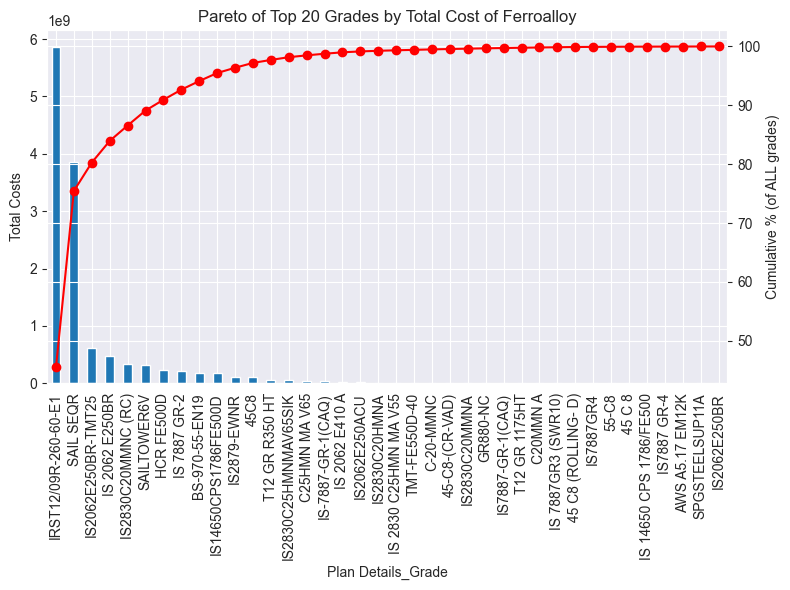

In [ ]:
grade_costs = master.groupby("Plan Details_Grade")["Ferro Alloy Cost (INR)"].sum().sort_values(ascending=False) # Group the master DataFrame by the 'Plan Details_Grade' column, sum the 'Ferro Alloy Cost (INR)' for each grade, and sort the resulting Series in descending order to get the total ferroalloy cost for each grade, with the most expensive grades at the top.

# cumulative percentage
cum_perc_wt = grade_costs.cumsum() / grade_costs.sum() * 100 # Calculate the cumulative percentage of the total cost for each grade by taking the cumulative sum of the 'grade_costs' Series, dividing it by the total sum of 'grade_costs', and multiplying by 100 to get the percentage. This gives us the cumulative percentage of total ferroalloy cost accounted for by each grade as we move down the list.

top20_weights = grade_costs.head(40)
top20_cumperc = cum_perc_wt.head(40)

# plot
fig, ax1 = plt.subplots(figsize=(8,6))

# top20_weights.plot(kind="bar", ax=ax1, color="lightgreen")
top20_weights.plot(kind="bar", ax=ax1)
ax1.set_ylabel("Total Costs")
ax1.set_title("Pareto of Top 20 Grades by Total Cost of Ferroalloy")

ax2 = ax1.twinx()
top20_cumperc.plot(color="red", marker="o", ax=ax2)
ax2.set_ylabel("Cumulative % (of ALL grades)")

plt.tight_layout()
plt.show()

# Calculate input and output weights for elements

In [91]:
master['COMB_all_Coke_wt'] = master['COMB_Nut Coke'] + master['COMB_Coke Breeze']
master['COMB_all_bauxite_wt'] = master['COMB_Calcined \nBauxite'] + master['COMB_Cal Baux\n10-40mm']
master['COMB_all_Lime_wt'] = master['COMB_LIME'] + master['COMB_Limestone'] + master['COMB_Limestone\nChip']

In [ ]:
master['final_input_weight_bath'] = master['TON'].fillna(0) - master['COMB_all_ferroalloy_wt'] - master['COMB_all_Coke_wt'] - master['COMB_all_bauxite_wt'] - master['COMB_all_Lime_wt'] - 0.75
# The 'final_input_weight_bath' column is calculated by taking the total weight of the bath ('TON'), filling any NaN values with 0, and then subtracting the weights of all ferroalloys, coke, bauxite, and lime used in the heat. The subtraction of 0.75 is likely a correction factor to account for any additional materials or discrepancies in the weight measurements. This column represents the final calculated weight of the bath inputs after accounting for all the major components.

In [93]:
master['final_output_weight_bath'] = master['final_input_weight_bath'] + master['BULK_all_ferroalloy_wt']

In [94]:
# Calculating the bulk input weight
master['input_C_weight_bulk'] = ((master['BULK_C'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_Mn_weight_bulk'] = ((master['BULK_MN'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_P_weight_bulk'] = ((master['BULK_P'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_S_weight_bulk'] = ((master['BULK_S'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_Si_weight_bulk'] = ((master['BULK_SI'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_V_weight_bulk'] = ((master['BULK_V'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_Cr_weight_bulk'] = ((master['BULK_CR'] * master['final_input_weight_bath']) / 100).clip(lower=0)
master['input_Ti_weight_bulk'] = ((master['BULK_TI'] * master['final_input_weight_bath']) / 100).clip(lower=0)

# Calculating the bulk output weight
master['output_C_weight_bulk'] = ((master['TRIM_C'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_Mn_weight_bulk'] = ((master['TRIM_MN'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_P_weight_bulk'] = ((master['TRIM_P'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_S_weight_bulk'] = ((master['TRIM_S'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_Si_weight_bulk'] = ((master['TRIM_SI'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_V_weight_bulk'] = ((master['TRIM_V'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_Cr_weight_bulk'] = ((master['TRIM_CR'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['output_Ti_weight_bulk'] = ((master['TRIM_TI'] * master['final_output_weight_bath']) / 100).clip(lower=0)


# Calculating the trim input weight
master['input_C_weight_trim'] = ((master['TRIM_C'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_Mn_weight_trim'] = ((master['TRIM_MN'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_P_weight_trim'] = ((master['TRIM_P'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_S_weight_trim'] = ((master['TRIM_S'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_Si_weight_trim'] = ((master['TRIM_SI'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_V_weight_trim'] = ((master['TRIM_V'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_Cr_weight_trim'] = ((master['TRIM_CR'] * master['final_output_weight_bath']) / 100).clip(lower=0)
master['input_Ti_weight_trim'] = ((master['TRIM_TI'] * master['final_output_weight_bath']) / 100).clip(lower=0)

# Calculating the trim output weight
master['output_C_weight_trim'] = ((master['FINL_C'] * master['TON']) / 100).clip(lower=0)
master['output_Mn_weight_trim'] = ((master['FINL_Mn'] * master['TON']) / 100).clip(lower=0)
master['output_P_weight_trim'] = ((master['FINL_P'] * master['TON']) / 100).clip(lower=0)
master['output_S_weight_trim'] = ((master['FINL_S'] * master['TON']) / 100).clip(lower=0)
master['output_Si_weight_trim'] = ((master['FINL_Si'] * master['TON']) / 100).clip(lower=0)
master['output_V_weight_trim'] = ((master['FINL_V'] * master['TON']) / 100).clip(lower=0)
master['output_Cr_weight_trim'] = ((master['FINL_Cr'] * master['TON']) / 100).clip(lower=0)
master['output_Ti_weight_trim'] = ((master['FINL_Ti'] * master['TON']) / 100).clip(lower=0)

# Read Ferro-Alloy chemistry data

In [95]:
df1 = pd.read_excel(join(PATH_INT, 'Ferro Alloy for Mack.xlsx'), sheet_name='Sheet1', usecols='A:J')
df2 = pd.read_excel(join(PATH_INT, 'Ferro Alloy for Mack.xlsx'), sheet_name='Sheet2')

In [96]:
df3 = pd.read_excel(r'/Users/Nikit_T_Nagrare/Downloads/Smooth_Sailing/BSP/SMS/SMS-3/01_raw/20251217/Ferro Alloy Oct-Dec 2025 data.xlsx')

In [97]:
df2 = pd.concat([df2,df3], axis=0)
df2.shape

(21974, 7)

In [98]:
fa_rename_mapping = {
    'SILICO MANGANESE, 10-50MM': ['SiMn\n12-25mm', 'Si-Mn\n25-50mm', 'Si-Mn\n10-50mm'],
    'SILICO MANGANESE, 10-50 MM, P:0.1% MAX.': ['SiMn LP\n25_50mm'],
    'FERRO-SILICON, SIZE : 25-50MM': ['Fe-Si', 'Fe-Si\n0-50mm'],
    'FERRO-MANGANESE, HIGH CARBON, 25-50MM': ['Fe-Mn\nHi-C', 'Fe-Mn\nLo-C'],
}

fa_rename_mapping

{'SILICO MANGANESE, 10-50MM': ['SiMn\n12-25mm',
  'Si-Mn\n25-50mm',
  'Si-Mn\n10-50mm'],
 'SILICO MANGANESE, 10-50 MM, P:0.1% MAX.': ['SiMn LP\n25_50mm'],
 'FERRO-SILICON, SIZE : 25-50MM': ['Fe-Si', 'Fe-Si\n0-50mm'],
 'FERRO-MANGANESE, HIGH CARBON, 25-50MM': ['Fe-Mn\nHi-C', 'Fe-Mn\nLo-C']}

In [99]:
reverse_mapping = {alloy: desc for desc, alloys in fa_rename_mapping.items() for alloy in alloys}
reverse_mapping

{'SiMn\n12-25mm': 'SILICO MANGANESE, 10-50MM',
 'Si-Mn\n25-50mm': 'SILICO MANGANESE, 10-50MM',
 'Si-Mn\n10-50mm': 'SILICO MANGANESE, 10-50MM',
 'SiMn LP\n25_50mm': 'SILICO MANGANESE, 10-50 MM, P:0.1% MAX.',
 'Fe-Si': 'FERRO-SILICON, SIZE : 25-50MM',
 'Fe-Si\n0-50mm': 'FERRO-SILICON, SIZE : 25-50MM',
 'Fe-Mn\nHi-C': 'FERRO-MANGANESE, HIGH CARBON, 25-50MM',
 'Fe-Mn\nLo-C': 'FERRO-MANGANESE, HIGH CARBON, 25-50MM'}

In [100]:
df1 = df1.fillna('NA')

In [101]:
df1 = df1[df1['MIC NAME'].isin(['Si', 'P', 'Al', 'C', 'S', 'Mn'])]

In [102]:
df2.tail(20)

,Date,Material,Material Desc,Inspection Lot,MERKNR,ORIGINAL_INPUT,VORGLFNR
1531,13-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865400,60,0.0,1.0
1532,13-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865400,70,1.2,1.0
1533,13-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865400,80,14.1,1.0
1534,13-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865400,100,0.7,1.0
1535,15-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865674,60,0.0,1.0
1536,15-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865674,70,6.4,1.0
1537,15-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865674,80,15.5,1.0
1538,15-12-2025,10211100040019,"SILICO MANGANESE, 10-50MM",10001865674,100,0.9,1.0
1539,15-12-2025,10210900040002,"FERRO-SILICON, SIZE : 25-50MM",10001865676,10,0.0,2.0
1540,15-12-2025,10210900040002,"FERRO-SILICON, SIZE : 25-50MM",10001865676,20,2.9,2.0


In [103]:
df2 = df2.drop_duplicates(subset=['Date', 'Material', 'Material Desc', 'Inspection Lot', 'MERKNR'], keep='first')

In [104]:
fa_df = df2.merge(
    df1[['MATERIAL', 'MIC NUMBER', 'MIC NAME']],
    left_on=['Material', 'MERKNR'],
    right_on=['MATERIAL', 'MIC NUMBER'],
    how='left',
).dropna(subset=['MIC NAME'])

In [105]:
fa_df_pivot = fa_df.rename(columns={'ORIGINAL_INPUT': 'FAProp'}).pivot_table(
    index=['Date', 'Material', 'Material Desc', 'Inspection Lot'],
    columns=['MIC NAME'],
    values=['FAProp'],
    fill_value=0
).reset_index()

In [106]:
# Flatten the MultiIndex in columns
fa_df_pivot.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in fa_df_pivot.columns]

In [107]:
day_fa = fa_df_pivot.groupby(
    ['Date', 'Material', 'Material Desc']
)[[col for col in fa_df_pivot.columns if col.startswith('FAProp_')]].mean().reset_index()

In [108]:
day_fa['FAProp_V'] = 0
day_fa['FAProp_Cr'] = 0
day_fa['FAProp_Ti'] = 0

In [109]:
day_fa.groupby('Material Desc')[[col for col in day_fa if col.startswith('FAProp')]].mean()

,FAProp_Al,FAProp_C,FAProp_Mn,FAProp_P,FAProp_S,FAProp_Si,FAProp_V,FAProp_Cr,FAProp_Ti
Material Desc,,,,,,,,,
"FERRO-MANGANESE, HIGH CARBON, 25-50MM",0.000000,5.911765,69.441765,0.353529,0.010000,0.623529,0.0,0.0,0.0
"FERRO-SILICON, SIZE : 25-50MM",1.046139,0.082383,0.000000,0.030110,0.002313,72.178999,0.0,0.0,0.0
"SILICO MANGANESE, 10-50 MM, P:0.1% MAX.",0.000000,1.950802,61.366303,0.078661,0.017697,17.149717,0.0,0.0,0.0
"SILICO MANGANESE, 10-50MM",0.000000,1.927509,60.768197,0.257510,0.016237,16.645272,0.0,0.0,0.0


In [110]:
# Step 1: Preprocess the `day_fa` DataFrame
day_fa['Date'] = pd.to_datetime(day_fa['Date'])  # Convert the Date column to datetime format
day_fa = day_fa.sort_values(by='Date')  # Sort the DataFrame by Date

In [111]:
day_fa[[col for col in day_fa if col.startswith('FAProp')]] = day_fa[[col for col in day_fa if col.startswith('FAProp')]]/100

## Weight dicts

In [112]:
# Step 2: Define the mapping and weights
fa_rename_mapping = {
    'SILICO MANGANESE, 10-50MM': ['SiMn\n12-25mm', 'Si-Mn\n25-50mm', 'Si-Mn\n10-50mm'],
    'SILICO MANGANESE, 10-50 MM, P:0.1% MAX.': ['SiMn LP\n25_50mm'],
    'FERRO-SILICON, SIZE : 25-50MM': ['Fe-Si', 'Fe-Si\n0-50mm'],
    'FERRO-MANGANESE, HIGH CARBON, 25-50MM': ['Fe-Mn\nHi-C', 'Fe-Mn\nLo-C'],
}

# Define the lookup table for element weights
weights = {
    "SiMn\n12-25mm": {"C": 0.02, "Mn": 0.6, "Si": 0.15, "V": 0, "Cr": 0, "Ti": 0},
    "SiMn LP\n25_50mm": {"C": 0.02, "Mn": 0.6, "Si": 0.15, "V": 0, "Cr": 0, "Ti": 0},
    "Si-Mn\n25-50mm": {"C": 0.02, "Mn": 0.6, "Si": 0.15, "V": 0, "Cr": 0, "Ti": 0},
    "Si-Mn\n10-50mm": {"C": 0.02, "Mn": 0.6, "Si": 0.15, "V": 0, "Cr": 0, "Ti": 0},
    "Fe-Si": {"C": 0.0015, "Mn": 0, "Si": 0.7, "V": 0, "Cr": 0, "Ti": 0},
    "Fe-Si\n0-50mm": {"C": 0.0015, "Mn": 0, "Si": 0.7, "V": 0, "Cr": 0, "Ti": 0},
    "Ferro\nVanadium": {"C": 0, "Mn": 0, "Si": 0, "V": 0.55, "Cr": 0, "Ti": 0},
    "Fe-Mn\nHi-C": {"C": 0.075, "Mn": 0.7, "Si": 0.015, "V": 0, "Cr": 0, "Ti": 0},
    "Fe-Mn\nLo-C": {"C": 0.001, "Mn": 0.7, "Si": 0.05, "V": 0, "Cr": 0, "Ti": 0},
    "Fe-Mn \nMb": {"C": 0, "Mn": 0.01, "Si": 0.01, "V": 0, "Cr": 0, "Ti": 0},
    "Fe-Cr\nHi-C": {"C": 0.08, "Mn": 0, "Si": 0.04, "V": 0, "Cr": 0.7, "Ti": 0},
    "Fe-Cr\nLo-C": {"C": 0.02, "Mn": 0, "Si": 0.04, "V": 0, "Cr": 0.7, "Ti": 0},
    "Ferro\nTitanium": {"C": 0.0025, "Mn": 0, "Si": 0.02, "V": 0, "Cr": 0, "Ti": 0.65},
    "Ferro\nNiobium": {"C": 0.0025, "Mn": 0, "Si": 0.03, "V": 0, "Cr": 0, "Ti": 0},
    "P.Coke": {"C": 0.95, "Mn": 0, "Si": 0, "V": 0, "Cr": 0, "Ti": 0},
}

# Convert to a DataFrame for easier manipulation
weights_df = pd.DataFrame(weights).T

In [113]:
# Step 3: Add columns for each ferroalloy and element
elements = ["C", "Mn", "Si", "V", "Cr", "Ti"]

# Add columns for each ferroalloy and element
for alloy in weights.keys():
    for element in elements:
        column_name = f"FAProp_{alloy}_{element}"  # Create column name
        master[column_name] = np.nan  # Initialize with NaN

In [114]:
# Step 4: Populate the columns with chemistry values
for idx, row in master.iterrows():
    # Get the date for the current row
    master_date = row['Date']
    
    # Filter day_fa to include only rows with Date <= master_date
    filtered_day_fa = day_fa[day_fa['Date'] <= master_date]
    
    # Iterate over each material description in fa_rename_mapping
    for material_desc, alloys in fa_rename_mapping.items():
        # Check if the material description exists in the filtered day_fa
        if material_desc in filtered_day_fa['Material Desc'].values:
            # Get the most recent sample for this material description
            recent_sample = filtered_day_fa[filtered_day_fa['Material Desc'] == material_desc].iloc[-1]
            
            # Populate the chemistry values for each alloy mapped to this material description
            for alloy in alloys:
                for element in elements:
                    column_name = f"FAProp_{alloy}_{element}"
                    master.at[idx, column_name] = recent_sample[f"FAProp_{element}"]

In [115]:
# Step 5: Handle alloys without sampling data
# For alloys without sampling data, populate the columns with static weights
for alloy in weights.keys():
    for element in elements:
        column_name = f"FAProp_{alloy}_{element}"
        master[column_name].fillna(weights[alloy][element], inplace=True)

In [116]:
# Step 6: Calculate input weights dynamically
# Initialize columns for input weights
for element in elements:
    master[f"input_{element}_alloy_bulk"] = 0  # Initialize with zeros

# Calculate input weights dynamically
for alloy in weights.keys():
    for element in elements:
        column_name = f"FAProp_{alloy}_{element}"  # Get the column name
        master[f"input_{element}_alloy_bulk"] += (
            master[f"BULK_{alloy}"] * master[column_name]
        )

In [117]:
# Step 6: Calculate input weights dynamically
# Initialize columns for input weights
for element in elements:
    master[f"input_{element}_alloy_trim"] = 0  # Initialize with zeros

# Calculate input weights dynamically
for alloy in weights.keys():
    for element in elements:
        column_name = f"FAProp_{alloy}_{element}"  # Get the column name
        master[f"input_{element}_alloy_trim"] += (
            master[f"TRIM_{alloy}"] * master[column_name]
        )

In [118]:
# Step 6: Calculate input weights dynamically
# Initialize columns for input weights
for element in elements:
    master[f"input_{element}_alloy_comb"] = 0  # Initialize with zeros

# Calculate input weights dynamically
for alloy in weights.keys():
    for element in elements:
        column_name = f"FAProp_{alloy}_{element}"  # Get the column name
        master[f"input_{element}_alloy_comb"] += (
            master[f"COMB_{alloy}"] * master[column_name]
        )

In [119]:
master

,_x,Heat \nNo.,CN,Plan Details_THK,Plan Details_WTH,Plan Details_LTH,Plan Details_CC,Plan Details_Grade,Charging Details_No,Charging Details_L/D,Charging Details_Condition,Charging Details_HM Wt,Charging Details_Time,Charging Details_Ch.Wt,Mixer Analysis_Si,Mixer Analysis_Mn,Mixer Analysis_P,Mixer Analysis_S,Return Heat Details_No,Return Heat Details_T,Return Heat Details_Wt,Tapping_Start,Tapping_End,Tapping_L/D,Tap.Temp_Min,Tap.Temp_Aim,Tap.Temp_Max,Blow Details_Start,Blow Details_End,Blow Details_Oxygen,Bath Details_Temp.,Bath Details_Time,Life_T/Hole,Life_Lance,Life_CN,CREATED BY,HEATNO,REHEAT_NO,BSP_HEATNO,BSP_REHEAT_NO,CONVERTOR_ID,LINING_LIFE,TAPPING_DATE,PROD_DATE,HEAT_YEAR,LANCE,NO_OF_BLOWS,BLOW_START_1,BLOW_END,BLOW_END_1,BLOW_START_2,BLOW_END_2,BLOW_START_3,BLOW_END_3,BLOW_START_4,BLOW_END_4,BLOW_START_5,BLOW_END_5,BL_OXYGEN_1,BL_OXYGEN_2,BL_OXYGEN_3,BL_OXYGEN_4,BL_OXYGEN_5,TAP_START,TAP_END,TOT_OXYGEN,TD_TEMP,TD_TEMP_TIME,LADLE_NO,ARGON_TEMP,ARGON_TEMP_TIME,ARGON_2TEMP,ARGON_2TEMP_TIME,AIM_GRADE,TAPPED_GRADE,HM_SI,HM_MN,HM_P,HM_S,CASTER_NO,CAST_START,CAST_END,BILLET_BLOOM,CASTING_PIECE,CASTING_WT,CASTING_STATUS,INS_UPD_DATE,LF_NO,LF_ARC_START,LF_ARC_END,RH_NO,RH_DEGASS_START,RH_DEGASS_END,CASTER_SEQ,STEEL_WT,HOT_METAL_LADLE,HEATNO_UPDATED_x,Date,Heat No,Grade,HM,COMB_Steel\nScrap,COMB_Chargeable\nSteel Scrap,COMB_Wear\n Scrap,COMB_NFScrap\nCu,COMB_Cu Mould,COMB_Ingot Cu,COMB_Cu Cathode,COMB_LIME,COMB_Limestone,COMB_Limestone\nChip,COMB_Calcined \nDolomite,COMB_Calcined \nBauxite,COMB_Cal Baux\n10-40mm,COMB_Cal Carb\nDS,COMB_Cal\nAl,COMB_Calcium\nSilicide,COMB_Dolomite \nRMP2 Gr,COMB_Iron Ore\nBF Grade,COMB_Iron Ore\nOH Grade,COMB_CASI\nWire,COMB_CAFE Cored\nWire,COMB_MG-97,COMB_P.Coke,COMB_Nut Coke,COMB_Coke Breeze,COMB_SiMn\n12-25mm,COMB_SiMn LP\n25_50mm,COMB_Si-Mn\n25-50mm,COMB_Si-Mn\n10-50mm,COMB_Fe-Si,COMB_Fe-Si\n0-50mm,COMB_Ferro\nVanadium,COMB_Fe-Mn\nHi-C,COMB_Fe-Mn\nLo-C,COMB_Fe-Mn \nMb,COMB_Fe-Cr\nHi-C,COMB_Fe-Cr\nLo-C,COMB_Ferro\nTitanium,COMB_Ferro\nNiobium,COMB_FEP,COMB_Al.\nShot,COMB_Al\nIngot,COMB_Al\nWire,COMB_Al\nCube,COMB_Pallet,COMB_LDSF,COMB_Ferro\nBoron,COMB_Coil\nFlipping,COMB_all_ferroalloy_wt,BULK_Steel\nScrap,BULK_Chargeable\nSteel Scrap,BULK_Wear\n Scrap,BULK_NFScrap\nCu,BULK_Cu Mould,BULK_Ingot Cu,BULK_Cu Cathode,BULK_LIME,BULK_Limestone,BULK_Limestone\nChip,BULK_Calcined \nDolomite,BULK_Calcined \nBauxite,BULK_Cal Baux\n10-40mm,BULK_Cal Carb\nDS,BULK_Cal\nAl,BULK_Calcium\nSilicide,BULK_Dolomite \nRMP2 Gr,BULK_Iron Ore\nBF Grade,BULK_Iron Ore\nOH Grade,BULK_CASI\nWire,BULK_CAFE Cored\nWire,BULK_MG-97,BULK_P.Coke,BULK_Nut Coke,BULK_Coke Breeze,BULK_SiMn\n12-25mm,BULK_SiMn LP\n25_50mm,BULK_Si-Mn\n25-50mm,BULK_Si-Mn\n10-50mm,BULK_Fe-Si,BULK_Fe-Si\n0-50mm,BULK_Ferro\nVanadium,BULK_Fe-Mn\nHi-C,BULK_Fe-Mn\nLo-C,BULK_Fe-Mn \nMb,BULK_Fe-Cr\nHi-C,BULK_Fe-Cr\nLo-C,BULK_Ferro\nTitanium,BULK_Ferro\nNiobium,BULK_FEP,BULK_Al.\nShot,BULK_Al\nIngot,BULK_Al\nWire,BULK_Al\nCube,BULK_Pallet,BULK_LDSF,BULK_Ferro\nBoron,BULK_Coil\nFlipping,BULK_all_ferroalloy_wt,TRIM_Steel\nScrap,TRIM_Chargeable\nSteel Scrap,TRIM_Wear\n Scrap,TRIM_NFScrap\nCu,TRIM_Cu Mould,TRIM_Ingot Cu,TRIM_Cu Cathode,TRIM_LIME,TRIM_Limestone,TRIM_Limestone\nChip,TRIM_Calcined \nDolomite,TRIM_Calcined \nBauxite,TRIM_Cal Baux\n10-40mm,TRIM_Cal Carb\nDS,TRIM_Cal\nAl,TRIM_Calcium\nSilicide,TRIM_Dolomite \nRMP2 Gr,TRIM_Iron Ore\nBF Grade,TRIM_Iron Ore\nOH Grade,TRIM_CASI\nWire,TRIM_CAFE Cored\nWire,TRIM_MG-97,TRIM_P.Coke,TRIM_Nut Coke,TRIM_Coke Breeze,TRIM_SiMn\n12-25mm,TRIM_SiMn LP\n25_50mm,TRIM_Si-Mn\n25-50mm,TRIM_Si-Mn\n10-50mm,TRIM_Fe-Si,TRIM_Fe-Si\n0-50mm,TRIM_Ferro\nVanadium,TRIM_Fe-Mn\nHi-C,TRIM_Fe-Mn\nLo-C,TRIM_Fe-Mn \nMb,TRIM_Fe-Cr\nHi-C,TRIM_Fe-Cr\nLo-C,TRIM_Ferro\nTitanium,TRIM_Ferro\nNiobium,TRIM_FEP,TRIM_Al.\nShot,TRIM_Al\nIngot,TRIM_Al\nWire,TRIM_Al\nCube,TRIM_Pallet,TRIM_LDSF,TRIM_Ferro\nBoron,TRIM_Coil\nFlipping,TRIM_all_ferroalloy_wt,_y,Heat\nNo.,Plan\nHeat,Heat Details_Final Grade,Heat Details_Ord.Type,Heat Details_Route,Caster De

# Recovery calculations

In [120]:
# Main bulk formula

master['recovery_bulk_%_Mn'] = ((master['output_Mn_weight_bulk'] - master['input_Mn_weight_bulk'])/master['input_Mn_alloy_bulk'])*100
master['recovery_bulk_%_C'] = ((master['output_C_weight_bulk'] - master['input_C_weight_bulk'])/master['input_C_alloy_bulk'])*100
master['recovery_bulk_%_Si'] = ((master['output_Si_weight_bulk'] - master['input_Si_weight_bulk'])/master['input_Si_alloy_bulk'])*100
master['recovery_bulk_%_V'] = ((master['output_V_weight_bulk'] - master['input_V_weight_bulk'])/master['input_V_alloy_bulk'])*100

In [121]:
# Main trim formula

master['recovery_trim_%_Mn'] = ((master['output_Mn_weight_trim'] - master['input_Mn_weight_trim'])/master['input_Mn_alloy_trim'])*100
master['recovery_trim_%_C'] = ((master['output_C_weight_trim'] - master['input_C_weight_trim'])/master['input_C_alloy_trim'])*100
master['recovery_trim_%_Si'] = ((master['output_Si_weight_trim'] - master['input_Si_weight_trim'])/master['input_Si_alloy_trim'])*100
master['recovery_trim_%_V'] = ((master['output_V_weight_trim'] - master['input_V_weight_trim'])/master['input_V_alloy_trim'])*100

In [122]:
# Main comb formula

master['recovery_comb_%_Mn'] = ((master['output_Mn_weight_trim'] - master['input_Mn_weight_bulk'])/master['input_Mn_alloy_comb'])*100
master['recovery_comb_%_C'] = ((master['output_C_weight_trim'] - master['input_C_weight_bulk'])/master['input_C_alloy_comb'])*100
master['recovery_comb_%_Si'] = ((master['output_Si_weight_trim'] - master['input_Si_weight_bulk'])/master['input_Si_alloy_comb'])*100
master['recovery_comb_%_V'] = ((master['output_V_weight_trim'] - master['input_V_weight_bulk'])/master['input_V_alloy_comb'])*100

In [123]:
master[[col for col in master if col.startswith('recovery')]] = master[[col for col in master if col.startswith('recovery')]].replace([np.inf, -np.inf], np.nan)

In [124]:
recovery_bulk_cols = ["recovery_bulk_%_C", "recovery_bulk_%_Mn" ,"recovery_bulk_%_Si" ,"recovery_bulk_%_V"]

recovery_trim_cols = ["recovery_trim_%_C", "recovery_trim_%_Mn" ,"recovery_trim_%_Si" ,"recovery_trim_%_V"]

recovery_comb_cols = ["recovery_comb_%_C", "recovery_comb_%_Mn" ,"recovery_comb_%_Si" ,"recovery_comb_%_V"]

top4_grades=['SAIL SEQR', 'IRST12/09R-260-60-E1', 'IS2062E250BR-TMT25','IS 7887 GR-2']

In [125]:
material_columns_bulk = ["BULK_"+col for col in material_columns]
material_columns_trim = ["TRIM_"+col for col in material_columns]

In [126]:
# Step 2: Filter rows where all material columns are NaN or ≤ 0
filtered_df = master[
    ~((master[material_columns_bulk].isna()) | (master[material_columns_bulk] <= 0)).all(axis=1)
]
filtered_df = filtered_df[filtered_df['Plan Details_Grade'].isin(top4_grades)]

# Step 3: Melt the DataFrame to make it long-form for easier analysis
melted_df = filtered_df.melt(
    id_vars=['Plan Details_Grade'],  # Keep the grade column as is
    value_vars=material_columns_bulk,    # Columns to unpivot (materials)
    var_name='Material',            # New column for material names
    value_name='Quantity'           # New column for material quantities
)

# Step 4: Filter out rows with null or ≤ 0 quantities
melted_df = melted_df[melted_df['Quantity'] > 0]

# Step 5: Group by grade and find unique materials
result = melted_df.groupby('Plan Details_Grade')['Material'].unique().reset_index()

# Step 6: Rename columns for clarity (optional)
result.columns = ['Grade', 'Unique_Materials']

In [127]:
for i,r in result.iterrows():
    print(r['Grade'])
    print(r['Unique_Materials'])
    print()

IRST12/09R-260-60-E1
['BULK_Fe-Mn\nHi-C' 'BULK_Fe-Si' 'BULK_Fe-Si\n0-50mm'
 'BULK_Ferro\nVanadium' 'BULK_Si-Mn\n10-50mm' 'BULK_SiMn LP\n25_50mm'
 'BULK_P.Coke']

IS 7887 GR-2
['BULK_Fe-Mn\nHi-C' 'BULK_Fe-Mn\nLo-C' 'BULK_Fe-Si' 'BULK_Si-Mn\n10-50mm'
 'BULK_SiMn LP\n25_50mm' 'BULK_P.Coke']

IS2062E250BR-TMT25
['BULK_Fe-Mn\nHi-C' 'BULK_Fe-Si' 'BULK_Fe-Si\n0-50mm'
 'BULK_Ferro\nVanadium' 'BULK_Si-Mn\n10-50mm' 'BULK_SiMn LP\n25_50mm'
 'BULK_P.Coke']

SAIL SEQR
['BULK_Fe-Cr\nHi-C' 'BULK_Fe-Mn\nHi-C' 'BULK_Fe-Si' 'BULK_Fe-Si\n0-50mm'
 'BULK_Ferro\nVanadium' 'BULK_Si-Mn\n10-50mm' 'BULK_SiMn LP\n25_50mm'
 'BULK_P.Coke']



In [128]:
# Step 2: Filter rows where all material columns are NaN or ≤ 0
filtered_df = master[
    ~((master[material_columns_trim].isna()) | (master[material_columns_trim] <= 0)).all(axis=1)
]
filtered_df = filtered_df[filtered_df['Plan Details_Grade'].isin(top4_grades)]

# Step 3: Melt the DataFrame to make it long-form for easier analysis
melted_df = filtered_df.melt(
    id_vars=['Plan Details_Grade'],  # Keep the grade column as is
    value_vars=material_columns_trim,    # Columns to unpivot (materials)
    var_name='Material',            # New column for material names
    value_name='Quantity'           # New column for material quantities
)

# Step 4: Filter out rows with null or ≤ 0 quantities
melted_df = melted_df[melted_df['Quantity'] > 0]

# Step 5: Group by grade and find unique materials
result = melted_df.groupby('Plan Details_Grade')['Material'].unique().reset_index()

# Step 6: Rename columns for clarity (optional)
result.columns = ['Grade', 'Unique_Materials']

In [129]:
for i,r in result.iterrows():
    print(r['Grade'])
    print(r['Unique_Materials'])
    print()

IRST12/09R-260-60-E1
['TRIM_Fe-Mn\nHi-C' 'TRIM_Fe-Mn\nLo-C' 'TRIM_Fe-Si' 'TRIM_Ferro\nTitanium'
 'TRIM_Ferro\nVanadium' 'TRIM_Si-Mn\n10-50mm' 'TRIM_P.Coke']

IS 7887 GR-2
['TRIM_Fe-Mn\nHi-C' 'TRIM_Fe-Mn\nLo-C' 'TRIM_Fe-Si' 'TRIM_Ferro\nTitanium'
 'TRIM_Si-Mn\n10-50mm' 'TRIM_P.Coke']

IS2062E250BR-TMT25
['TRIM_Fe-Mn\nHi-C' 'TRIM_Fe-Mn\nLo-C' 'TRIM_Fe-Si' 'TRIM_Ferro\nTitanium'
 'TRIM_Si-Mn\n10-50mm' 'TRIM_P.Coke']

SAIL SEQR
['TRIM_Fe-Mn\nLo-C' 'TRIM_Fe-Si' 'TRIM_Ferro\nTitanium'
 'TRIM_Ferro\nVanadium' 'TRIM_Si-Mn\n10-50mm' 'TRIM_P.Coke']



In [130]:
master.to_csv(join(PATH_INT, "master_20260107.csv"), index=False)

In [131]:
def has_mixed_types(series):
    # Get unique types in the column, ignoring NaN
    types = set(type(x) for x in series.dropna())
    return len(types) > 1

# Detect problematic columns
problematic_cols = [col for col in master.columns if has_mixed_types(master[col])]

print("Columns with mixed types:", problematic_cols)

# Convert only problematic columns to string
for col in problematic_cols:
    master[col] = master[col].astype(str)

# Now save to parquet
master.to_parquet("master_20260107.parquet")

Columns with mixed types: ['BSP_HEATNO', 'LINING_LIFE', 'TAP_START', 'TAP_END', 'TD\nHYD\nppm', 'TON excluding HB TB']


# Recovery timeline

## Bulk Mn Recovery - R260

In [ ]:
fig = px.line(
    master[(master['Plan Details_Grade'] == 'IRST12/09R-260-60-E1') & (master['recovery_bulk_%_Mn'].between(20, 100))],
    x='Charging Details_Time',
    y='recovery_bulk_%_Mn',
    labels={
        'Charging Details_Time': 'Time',
        'recovery_bulk_%_Mn': 'Recovery Mn % in Bulk Addition'
    },
    title='Bulk Addition Mn % Recovery Percentage over time',
    width=850,  # Adjust the width
    # height=600   # Adjust the height
)

# Set the background color to white and keep the gridlines
fig.update_layout(
    plot_bgcolor="white",  # Background of the plot area
    paper_bgcolor="white",  # Background of the entire figure
    xaxis=dict(
        showgrid=True,  # Ensure the x-axis grid is visible
        gridcolor="lightgray"  # Set the gridline color for the x-axis
    ),
    yaxis=dict(
        showgrid=True,  # Ensure the y-axis grid is visible
        gridcolor="lightgray"  # Set the gridline color for the y-axis
    )
)
# Show the plot
fig.show()

## Trim Mn Recovery - R260

In [ ]:
fig = px.line(
    master[(master['Plan Details_Grade'] == 'IRST12/09R-260-60-E1') & (master['recovery_trim_%_Mn'].between(20, 100))],
    x='Charging Details_Time',
    y='recovery_trim_%_Mn',
    labels={
        'Charging Details_Time': 'Time',
        'recovery_trim_%_Mn': 'Recovery Mn % in Trim Addition'
    },
    title='Trim Addition Mn % Recovery Percentage over time',
    width=850,  # Adjust the width
    # height=600   # Adjust the height
)

# Set the background color to white and keep the gridlines
fig.update_layout(
    plot_bgcolor="white",  # Background of the plot area
    paper_bgcolor="white",  # Background of the entire figure
    xaxis=dict(
        showgrid=True,  # Ensure the x-axis grid is visible
        gridcolor="lightgray"  # Set the gridline color for the x-axis
    ),
    yaxis=dict(
        showgrid=True,  # Ensure the y-axis grid is visible
        gridcolor="lightgray"  # Set the gridline color for the y-axis
    )
)
# Show the plot
fig.show()

# Cost Optimization

## Grade DF

In [ ]:
# Define the data for the specified grades without TLiq and PPM elements
# grades_data = {
#     "SAIL SEQR": {
#         "Aim Min.": {"%C": 0.22, "%Mn": 0.81, "%P": None, "%S": None, "%Si": 0.20, "%Al": None, "%Cr": None, "%Ti": None},
#         "Aim Max.": {"%C": 0.24, "%Mn": 0.85, "%P": 0.030, "%S": 0.030, "%Si": 0.25, "%Al": None, "%Cr": None, "%Ti": None}
#     },
#     "IRST12/09R-260-60-E1": {
#         "Aim Min.": {"%C": 0.68, "%Mn": 1.08, "%P": None, "%S": None, "%Si": 0.30, "%Al": None, "%V": 0.024, "%Cr": None, "%Ti": None},
#         "Aim Max.": {"%C": 0.70, "%Mn": 1.12, "%P": 0.020, "%S": 0.020, "%Si": 0.35, "%Al": 0.002, "%V": 0.026, "%Cr": None, "%Ti": None}
#     },
#     "IS2062E250BR-TMT25": {
#         "Aim Min.": {"%C": 0.18, "%Mn": 0.65, "%P": None, "%S": None, "%Si": 0.15, "%Cr": None, "%Ti": None},
#         "Aim Max.": {"%C": 0.19, "%Mn": 0.70, "%P": 0.030, "%S": 0.030, "%Si": 0.20, "%Cr": None, "%Ti": None}
#     },
#     "IS 7887 GR-2": {
#         "Aim Min.": {"%C": 0.05, "%Mn": 0.30, "%P": None, "%S": None, "%Si": 0.05, "%Al": None, "%Cr": None, "%Ti": None},
#         "Aim Max.": {"%C": 0.06, "%Mn": 0.35, "%P": 0.035, "%S": 0.025, "%Si": 0.06, "%Al": None, "%Cr": None, "%Ti": None}
#     }
# }

grades_data = {
    "SAIL SEQR": {
        "Aim Min.": {"%C": 0.21, "%Mn": 0.79, "%P": None, "%S": None, "%Si": 0.19, "%Al": None, "%V": None, "%Ti": None, "%Cr": None},
        "Aim Max.": {"%C": 0.24, "%Mn": 0.85, "%P": 0.03, "%S": 0.03, "%Si": 0.25, "%Al": None, "%V": None, "%Ti": None, "%Cr": None}
    },
    "IRST12/09R-260-60-E1": {
        "Aim Min.": {"%C": 0.66, "%Mn": 1.05, "%P": None, "%S": None, "%Si": 0.29, "%Al": None, "%V": 0.022, "%Ti": None, "%Cr": None},
        "Aim Max.": {"%C": 0.70, "%Mn": 1.12, "%P": 0.02, "%S": 0.02, "%Si": 0.35, "%Al": 0.002, "%V": 0.026, "%Ti": None, "%Cr": None}
    },
    "IS2062E250BR-TMT25": {
        "Aim Min.": {"%C": 0.18, "%Mn": 0.64, "%P": None, "%S": None, "%Si": 0.16, "%Al": None, "%V": None, "%Ti": None, "%Cr": None},
        "Aim Max.": {"%C": 0.19, "%Mn": 0.70, "%P": 0.03, "%S": 0.03, "%Si": 0.20, "%Al": None, "%V": None, "%Ti": None, "%Cr": None}
    },
    "IS 7887 GR-2": {
        "Aim Min.": {"%C": 0.05, "%Mn": 0.31, "%P": None, "%S": None, "%Si": 0.04, "%Al": None, "%V": None, "%Ti": None, "%Cr": None},
        "Aim Max.": {"%C": 0.06, "%Mn": 0.35, "%P": 0.035, "%S": 0.025, "%Si": 0.06, "%Al": None, "%V": None, "%Ti": None, "%Cr": None}
    }
}

# Convert the dictionary to a DataFrame
grades_df = pd.DataFrame.from_dict({(i, j): grades_data[i][j] 
                                    for i in grades_data.keys() 
                                    for j in grades_data[i].keys()},
                                   orient='index')

grades_df = grades_df.fillna(0)

grades_df = grades_df/100

## Data subset for testing

In [ ]:
# Define the top 4 grades
top4_grades = ['IRST12/09R-260-60-E1', 'SAIL SEQR', 'IS2062E250BR-TMT25', 'IS 7887 GR-2']

# Filter the DataFrame for the top 4 grades
filtered_df = df_cleaned[df_cleaned['Plan Details_Grade'].isin(top4_grades)].copy()

# Filter out invalid or small TON values
filtered_df = filtered_df.dropna(subset=['TON'])
filtered_df = filtered_df[filtered_df['TON'] > 100].copy()
filtered_df = filtered_df.reset_index(drop=True)

# Limit rows for testing (optional)
filtered_df = filtered_df[filtered_df['Charging Details_Time'] >= '2024-01-01']#.head(20)
print('filtered_df', filtered_df.shape)

# Ensure material_columns are prefixed with 'COMB_' when accessing the DataFrame
prefixed_material_columns = [f"COMB_{material}" for material in material_columns]

# Update price_dict to include 'COMB_' prefix
prefixed_price_dict = {f"COMB_{k}": v for k, v in price_dict.items()}

# Create a new column to store the list of materials added
def get_materials_added(row):
    # Check for non-zero and non-empty values in material_columns
    return [material for material in prefixed_material_columns if not pd.isna(row.get(material)) and row[material] != 0]

# Apply the function to each row
filtered_df['Materials_To_Be_Added'] = filtered_df.apply(get_materials_added, axis=1)

## Optimizer

In [ ]:
# Generate a timestamp
txt_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Set up logging with a timestamp in the filename
log_filename = f'optimization_log_{txt_timestamp}.txt'
logging.basicConfig(filename=log_filename, level=logging.DEBUG, format='%(message)s')

# Create a list to store detailed results for each heat
detailed_results = []

# Function to calculate optimal material additions using PuLP
def calculate_optimal_additions_pulp(row, grade):
    try:
        # Get the target chemistry for the grade
        aim_min = grades_df.loc[(grade, "Aim Min.")].fillna(0)  # Already in proportions
        aim_max = grades_df.loc[(grade, "Aim Max.")].fillna(0)  # Already in proportions
    except KeyError:
        raise KeyError(f"Grade {grade} not found in grades_df or Aim Min./Max. missing.")
    
    heat_no = str(row['Heat \nNo.']).replace('\n', '_')  # Replace invalid characters
    logging.debug("Heat No: %s, Aim Min: %s, Aim Max: %s", heat_no, aim_min, aim_max)
    
    # Use pre-calculated final input weight in TON
    final_input_weight_in_ton = row['final_input_weight_bath']
    
    # Check for NaN values in the components
    if pd.isna(final_input_weight_in_ton):
        detailed_results.append({
            "Heat No": row['Heat \nNo.'],
            "Grade": grade,
            "Caster Weight": row['TON'],
            "Calc Steel Ton": None,
            "Status": "Invalid",
            "Reason": "NaN value in weight components",
            "Target Min Weight": None,
            "Target Max Weight": None,
            "Input Chemistry Weight": None,
            "Output Chemistry Weight": None,
            "Input Chemistry Perc": None,
            "Output Chemistry Perc": None,
            "Optimized Chemistry Perc": None,
            "Available Materials": None,
            "Optimal Solution Weight": None,
            "Original Cost": None,
            "New Cost": None,
            "Cost Delta": None,
            **{f'Original_{material}': None for material in prefixed_material_columns},
            **{f'Optimal_{material}': None for material in prefixed_material_columns},
            **{f'Delta_{material}': None for material in prefixed_material_columns}
        })
        return None  # Invalid weight components

    # Use pre-calculated current chemistry (input weights in TON)
    input_element_weight = pd.Series({
        'input_C_weight': row['input_C_weight_bulk'],
        'input_Mn_weight': row['input_Mn_weight_bulk'],
        'input_Si_weight': row['input_Si_weight_bulk'],
        'input_V_weight': row['input_V_weight_bulk'],
        'input_Cr_weight': row['input_Cr_weight_bulk'],
        'input_Ti_weight': row['input_Ti_weight_bulk']
    }).fillna(0)

    # Use pre-calculated output/final chemistry (output weights in TON)
    output_element_weight = pd.Series({
        'output_C_weight': row['output_C_weight_trim'],
        'output_Mn_weight': row['output_Mn_weight_trim'],
        'output_Si_weight': row['output_Si_weight_trim'],
        'output_V_weight': row['output_V_weight_trim'],
        'output_Cr_weight': row['output_Cr_weight_trim'],
        'output_Ti_weight': row['output_Ti_weight_trim']
    }).fillna(0)

    # Use pre-calculated total steel weight in TON
    ton = row['TON']
    if not pd.api.types.is_number(ton) or ton <= 0:
        raise ValueError(f"Invalid TON value: {ton}")

    # Calculate input chemistry (proportions)
    input_chemistry = {element: input_element_weight[f'input_{element[1:]}_weight'] * 100 / ton for element in ['%C', '%Mn', '%Si', '%V', '%Cr', '%Ti']}

    # Calculate originally achieved chemistry (proportions)
    output_chemistry = {element: row[f'output_{element[1:]}_weight_trim'] * 100 / ton for element in ['%C', '%Mn', '%Si', '%V', '%Cr', '%Ti']}

    # Debugging: Print input and output chemistry
    logging.debug("Heat No: %s, Input Chemistry: %s", heat_no, input_chemistry)
    logging.debug("Heat No: %s, Output Chemistry: %s", heat_no, output_chemistry)

    # Adjust aim_min if the achieved value is already lower
    achieved_values = pd.Series(output_chemistry).fillna(0)
    for element in aim_min.index:
        if element in achieved_values.index and achieved_values[element] < aim_min[element]:
            aim_min[element] = achieved_values[element]

    # Adjust aim_max if the current chemistry is already higher
    for element in aim_max.index:
        if element in input_element_weight.index and input_element_weight[element] > aim_max[element]:
            aim_max[element] = input_element_weight[element]

    target_min = aim_min * ton  # Keep in TON
    target_max = aim_max * ton  # Keep in TON
    
    # Debugging: Print target_min and target_max
    logging.debug("Heat No: %s, Target Min Weight: %s, Target Max Weight: %s", heat_no, target_min, target_max)

    # Get the materials available for this heat
    materials = row['Materials_To_Be_Added']
    
    if not materials:
        detailed_results.append({
            "Heat No": row['Heat \nNo.'],
            "Grade": grade,
            "Caster Weight": row['TON'],
            "Calc Steel Ton": ton,
            "Status": "No materials available",
            "Reason": "No materials were available for optimization",
            "Target Min Weight": target_min.to_dict(),
            "Target Max Weight": target_max.to_dict(),
            "Input Chemistry Weight": input_element_weight.to_dict(),
            "Output Chemistry Weight": output_element_weight.to_dict(),
            "Input Chemistry Perc": input_chemistry,
            "Output Chemistry Perc": output_chemistry,
            "Optimized Chemistry Perc": None,
            "Available Materials": None,
            "Optimal Solution Weight": None,
            "Original Cost": None,
            "New Cost": None,
            "Cost Delta": None,
            **{f'Original_{material}': row.get(material, 0) for material in prefixed_material_columns},
            **{f'Optimal_{material}': 0 for material in prefixed_material_columns},
            **{f'Delta_{material}': 0 for material in prefixed_material_columns}
        })
        return None  # No materials available for this heat

    # Create a PuLP problem
    Lp_prob = p.LpProblem(f"Material_Optimization_Heat_{heat_no}", p.LpMinimize)

    # Define decision variables for each material
    material_vars = {material: p.LpVariable(material, lowBound=0) for material in materials}

    # Objective Function: Minimize total cost of materials added
    Lp_prob += p.lpSum(material_vars[material] * prefixed_price_dict.get(material, 0) for material in materials)

    # Constraints: Ensure final chemistry meets target specifications
    element_list = ['%C', '%Mn', '%Si', '%V', '%Cr', '%Ti']
    infeasible_elements = []
    for element in element_list:
        recovery_col = f'recovery_comb_%_{element[1:]}'  # Remove '%' for recovery column names
        recovery_rate = row.get(recovery_col, 1) / 100  # Default to 100% recovery if not provided

        # Fill NaN recovery rates with zero
        if pd.isna(recovery_rate) or recovery_rate < 0:
            recovery_rate = 0

        # Skip adding constraints for this element if target values are zero
        if target_min[element] == 0 and target_max[element] == 0:
            continue

        # Calculate the total contribution of each element from the materials added
        total_contribution = 0
        for material in materials:
            fa_column = f"FAProp_{material[5:]}_{element[1:]}"  # Map COMB_ to FAProp_
            material_contribution = row.get(fa_column, 0) * recovery_rate
            if not pd.api.types.is_number(material_contribution) or pd.isna(material_contribution):
                material_contribution = 0  # Default to 0 if invalid
            total_contribution += material_vars[material] * material_contribution

        # Relax the upper bound if the input chemistry is already greater than the Target Max Weight
        if input_element_weight[f'input_{element[1:]}_weight'] <= target_max[element]:
            Lp_prob += (input_element_weight[f'input_{element[1:]}_weight'] + total_contribution) <= target_max[element]

        # Always enforce the lower bound constraint
        Lp_prob += (input_element_weight[f'input_{element[1:]}_weight'] + total_contribution) >= target_min[element]

    # Solve the problem
    status = Lp_prob.solve(p.PULP_CBC_CMD(msg=False))

    # Calculate original cost (materials are already in TON)
    original_cost = sum(row.get(material, 0) * prefixed_price_dict.get(material, 0) for material in prefixed_material_columns)

    # Check if the solution is optimal
    if p.LpStatus[status] == 'Optimal':
        optimal_solution = {material: p.value(material_vars[material]) for material in materials}
        new_cost = sum(optimal_solution[material] * prefixed_price_dict.get(material, 0) for material in materials)
        cost_delta = original_cost - new_cost

        # Calculate the optimized new chemistry
        optimized_chemistry = {}
        for element in element_list:
            total_contribution = 0
            for material in materials:
                fa_column = f"FAProp_{material[5:]}_{element[1:]}"  # Map COMB_ to FAProp_
                material_contribution = row.get(fa_column, 0) * recovery_rate
                if not pd.api.types.is_number(material_contribution) or pd.isna(material_contribution):
                    material_contribution = 0  # Default to 0 if invalid
                total_contribution += optimal_solution.get(material, 0) * material_contribution
            optimized_chemistry[element] = (input_element_weight[f'input_{element[1:]}_weight'] + total_contribution) * 100 / ton

        # Add optimal material columns and quantity delta
        for material in prefixed_material_columns:
            optimal_quantity = optimal_solution.get(material, 0)  # Default to 0 if not found
            original_quantity = row.get(material, 0)  # Default to 0 if not found
            quantity_delta = original_quantity - optimal_quantity
            row[f'Original_{material}'] = original_quantity
            row[f'Optimal_{material}'] = optimal_quantity
            row[f'Delta_{material}'] = quantity_delta

        detailed_results.append({
            "Heat No": row['Heat \nNo.'],
            "Grade": grade,
            "Caster Weight": row['TON'],
            "Calc Steel Ton": ton,
            "Status": "Optimal",
            "Reason": None,
            "Target Min Weight": target_min.to_dict(),
            "Target Max Weight": target_max.to_dict(),
            "Input Chemistry Weight": input_element_weight.to_dict(),
            "Output Chemistry Weight": output_element_weight.to_dict(),
            "Input Chemistry Perc": input_chemistry,
            "Output Chemistry Perc": output_chemistry,
            "Optimized Chemistry Perc": optimized_chemistry,
            "Available Materials": materials,
            "Optimal Solution Weight": optimal_solution,
            "Original Cost": original_cost,
            "New Cost": new_cost,
            "Cost Delta": cost_delta,
            **{f'Original_{material}': row.get(material, 0) for material in prefixed_material_columns},
            **{f'Optimal_{material}': optimal_solution.get(material, 0) for material in prefixed_material_columns},
            **{f'Delta_{material}': row.get(material, 0) - optimal_solution.get(material, 0) for material in prefixed_material_columns}
        })
        return optimal_solution
    else:
        # Identify the elements causing infeasibility with detailed reasons
        infeasible_elements = []
        for element in element_list:
            total_contribution = 0
            for material in materials:
                fa_column = f"FAProp_{material[5:]}_{element[1:]}"  # Map COMB_ to FAProp_
                material_contribution = row.get(fa_column, 0) * recovery_rate
                if not pd.api.types.is_number(material_contribution) or pd.isna(material_contribution):
                    material_contribution = 0  # Default to 0 if invalid
                total_contribution += p.value(material_vars[material]) * material_contribution

            # Calculate the final value for the element
            final_value = input_element_weight[f'input_{element[1:]}_weight'] + total_contribution

            # Check if the constraints for this element are violated
            if final_value < target_min[element]:
                infeasible_elements.append(f"{element} < Target Min Weight ({final_value:.4f} < {target_min[element]:.4f})")
            elif final_value > target_max[element]:
                infeasible_elements.append(f"{element} > Target Max Weight ({final_value:.4f} > {target_max[element]:.4f})")

        # Capture infeasibility details and set optimal materials to zero
        for material in prefixed_material_columns:
            row[f'Original_{material}'] = row.get(material, 0)
            row[f'Optimal_{material}'] = 0
            row[f'Delta_{material}'] = 0

        detailed_results.append({
            "Heat No": row['Heat \nNo.'],
            "Grade": grade,
            "Caster Weight": row['TON'],
            "Calc Steel Ton": ton,
            "Status": "Infeasible",
            "Reason": f"Infeasible due to elements: {', '.join(infeasible_elements)}",
            "Target Min Weight": target_min.to_dict(),
            "Target Max Weight": target_max.to_dict(),
            "Input Chemistry Weight": input_element_weight.to_dict(),
            "Output Chemistry Weight": output_element_weight.to_dict(),
            "Input Chemistry Perc": input_chemistry,
            "Output Chemistry Perc": output_chemistry,
            "Optimized Chemistry Perc": None,
            "Available Materials": materials,
            "Optimal Solution Weight": None,
            "Original Cost": original_cost,
            "New Cost": None,
            "Cost Delta": None,
            **{f'Original_{material}': row.get(material, 0) for material in prefixed_material_columns},
            **{f'Optimal_{material}': 0 for material in prefixed_material_columns},
            **{f'Delta_{material}': 0 for material in prefixed_material_columns}
        })
        return None

# Apply the function to each row
for index, row in filtered_df.iterrows():
    calculate_optimal_additions_pulp(row, row['Plan Details_Grade'])

# Convert the detailed results into a DataFrame for better readability
detailed_results_df = pd.DataFrame(detailed_results)

# Reorder columns to ensure material columns are next to each other
# columns_order = ['Heat No', 'Grade', 'Caster Weight', 'Calc Steel Ton','Available Materials', 'Status', 'Reason', 'Target Min Weight', 'Target Max Weight', 'Input Chemistry Weight', 'Output Chemistry Weight', 'Input Chemistry', 'Output Chemistry', 'Optimized Chemistry', 'Optimal Solution Weight', 'Original Cost', 'New Cost', 'Cost Delta']
columns_order = ['Heat No', 'Grade', 'Caster Weight', 'Calc Steel Ton','Available Materials', 'Status', 'Reason', 'Target Min Weight', 'Target Max Weight', 'Input Chemistry Weight', 'Output Chemistry Weight', 'Optimal Solution Weight', 'Original Cost', 'New Cost', 'Cost Delta']
for material in prefixed_material_columns:
    columns_order.extend([f'Original_{material}', f'Optimal_{material}', f'Delta_{material}'])

detailed_results_df = detailed_results_df[columns_order]

# Save the detailed results to a CSV file
detailed_results_df.to_csv(join(PATH_INT, f'detailed_results_{txt_timestamp}_comb.csv'), index=False)

# Log the completion of the process
logging.debug(f"Optimization process completed. Detailed results saved to detailed_results_{txt_timestamp}_comb.csv")

In [ ]:
detailed_results_df[detailed_results_df['Grade']=='IRST12/09R-260-60-E1']['Cost Delta'].median()

In [ ]:
# Create the interactive line plot
fig = px.line(
    detailed_results_df.sort_values('Heat No')[detailed_results_df['Grade'] == "IRST12/09R-260-60-E1"].tail(500).rename(columns={'New Cost':'Optimized Cost'}),
    x='Heat No',  # X-axis: Heat numbers
    y=['Optimized Cost', 'Original Cost'],  # Y-axis: Original and New Costs
    title=f'Original vs Optimized Costs for Last 500 Heats of Grade {grade} in Oct 2025',
    labels={'value': 'Cost (INR)', 'Heat No': 'Heat Number'},  # Axis labels
    # markers=True  # Add markers to the lines
)

# Customize the legend
fig.update_layout(
    legend_title_text='Cost',
    xaxis=dict(tickangle=45),  # Rotate x-axis labels for better readability
    template='plotly_white',  # Use a clean white background
    title_font=dict(size=18),  # Title font size
    xaxis_title_font=dict(size=14),  # X-axis label font size
    yaxis_title_font=dict(size=14)  # Y-axis label font size
)

# Show the plot

fig.show()

In [3]:
import pandas as pd
df = pd.read_csv(r'F:\SMS-3\notebooks\master_20260107.csv')
df

C:\Users\b037052\AppData\Local\Temp\ipykernel_18400\2867017573.py:2: DtypeWarning: Columns (0: Return Heat Details_No, 1: CREATED BY, 2: BLOW_END, 3: BLOW_START_3, 4: BLOW_END_3, 5: BLOW_START_4, 6: BLOW_END_4, 7: Heat
No., 8: Heat Details_Final Grade, 9: Heat Details_Ord.Type, 10: Heat Details_Route, 11: Caster Details_Start, 12: Caster Details_End, 13: Caster Details_S/OPEN, 14: Caster Details_End Type, 15: Caster Details_EMS 1, 16: Caster Details_EMS 2, 17: Caster Details_EMS 3, 18: Caster Details_EMS 4, 19: Tundish_No., 20: Tundish_Supplier, 21: Tundish_Lining Type, 22: Tundish_Changed?, 23: Tundish_Position, 24: Steel Ladle_Type, 25: Steel Ladle_Condition, 26: Prev
Route, 27: Created By, 28: Ended By, 29: LF_HEAT_NO, 30: LF_PURGING_TYPE, 31: LF_ARRIVAL_DTM, 32: LF_DISPATCH_DTM) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'F:\SMS-3\notebooks\master_20260107.csv')


,_x,Heat \nNo.,CN,Plan Details_THK,Plan Details_WTH,Plan Details_LTH,Plan Details_CC,Plan Details_Grade,Charging Details_No,Charging Details_L/D,...,recovery_bulk_%_Si,recovery_bulk_%_V,recovery_trim_%_Mn,recovery_trim_%_C,recovery_trim_%_Si,recovery_trim_%_V,recovery_comb_%_Mn,recovery_comb_%_C,recovery_comb_%_Si,recovery_comb_%_V
0,1.0,C056528,A,150.0,150.0,12000.0,CK2,SAIL SEQR,56552.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,C056529,B,105.0,105.0,11700.0,CK1,IS2830C20MMNC (RC),56553.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,C056530,C,300.0,335.0,9000.0,CV1,45C8,56554.0,8.0,...,50.999278,NaN,134.809200,74.412953,115.976242,NaN,93.075863,85.785126,63.530314,NaN
3,4.0,C056531,A,150.0,150.0,12000.0,CK2,SAIL SEQR,56555.0,6.0,...,41.564662,NaN,77.156819,51.649333,51.178277,NaN,80.595316,78.934876,43.331698,NaN
4,5.0,C056532,B,300.0,335.0,9000.0,CV1,45C8,56556.0,6.0,...,58.532237,NaN,186.376056,116.104450,67.228537,NaN,99.634161,99.754312,60.433219,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46210,1759.0,C111039,B,300.0,335.0,10610.0,CV2,IRST12/09R-260-60-E1,NaN,4.0,...,63.664451,98.946335,28.794857,120.686789,63.483306,NaN,95.913195,100.178189,63.628217,87.895500
46211,1760.0,C111040,A,300.0,335.0,10610.0,CV1,IRST12/09R-260-60-E1,NaN,1.0,...,63.682987,106.934565,99.588119,135.085307,53.929270,NaN,93.279721,96.942808,62.204317,107.871750
46212,1761.0,C111041,C,105.0,105.0,11700.0,CK2,SAIL SEQR,NaN,9.0,...,44.018319,NaN,100.831079,97.605281,39.504247,NaN,87.766017,83.807467,42.654313,NaN
46213,1762.0,C111042,B,300.0,335.0,10610.0,CV2,IRST12/09R-260-60-E1,NaN,3.0,...,57.137765,90.291221,106.522401,89.455309,84.717606,NaN,87.333818,91.079999,63.347667,95.125000


In [7]:
df_col_list = df.columns.to_list()

In [8]:
df_col_list


['_x',
 'Heat \nNo.',
 'CN',
 'Plan Details_THK',
 'Plan Details_WTH',
 'Plan Details_LTH',
 'Plan Details_CC',
 'Plan Details_Grade',
 'Charging Details_No',
 'Charging Details_L/D',
 'Charging Details_Condition',
 'Charging Details_HM Wt',
 'Charging Details_Time',
 'Charging Details_Ch.Wt',
 'Mixer Analysis_Si',
 'Mixer Analysis_Mn',
 'Mixer Analysis_P',
 'Mixer Analysis_S',
 'Return Heat Details_No',
 'Return Heat Details_T',
 'Return Heat Details_Wt',
 'Tapping_Start',
 'Tapping_End',
 'Tapping_L/D',
 'Tap.Temp_Min',
 'Tap.Temp_Aim',
 'Tap.Temp_Max',
 'Blow Details_Start',
 'Blow Details_End',
 'Blow Details_Oxygen',
 'Bath Details_Temp.',
 'Bath Details_Time',
 'Life_T/Hole',
 'Life_Lance',
 'Life_CN',
 'CREATED BY',
 'HEATNO',
 'REHEAT_NO',
 'BSP_HEATNO',
 'BSP_REHEAT_NO',
 'CONVERTOR_ID',
 'LINING_LIFE',
 'TAPPING_DATE',
 'PROD_DATE',
 'HEAT_YEAR',
 'LANCE',
 'NO_OF_BLOWS',
 'BLOW_START_1',
 'BLOW_END',
 'BLOW_END_1',
 'BLOW_START_2',
 'BLOW_END_2',
 'BLOW_START_3',
 'BLOW_END_